# Taller 1 · Del voltaje crudo a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [ ]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

descargado: taller1_datos.h5
descargado: verificacion.py
Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [ ]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*



_Escriban aquí su prompt:_

> Trabajo en Python dentro de Google Colab y tengo un archivo HDF5 cuya ruta está guardada en una variable llamada ARCHIVO. Haz un código que muestre los atributos que tiene el archivo junto con el valor de cada uno, recorra y liste todo el contenido del archivo HDF5 incluyendo los atributos que tenga cada grupo, muestre qué elementos hay dentro del grupo estimulos, determine cuántos ensayos hay usando la información disponible dentro de ese grupo, muestre cuántas condiciones distintas de estímulo se presentaron y calcule cuánto dura un ensayo completo y cuánto dura específicamente el estímulo usando la información almacenada en el archivo. Organiza los resultados por secciones con print(), muestra las unidades cuando correspondan y explica mediante comentarios sencillos qué hace cada línea del código.

In [ ]:
import h5py  #Importamos h5py para trabajar con archivos HDF5

with h5py.File(ARCHIVO, "r") as archivo:  #Abrimos el archivo en modo lectura

    #¿Qué atributos tiene el archivo y qué valor tiene cada uno?
    print("1. Atributos del archivo:")
    for nombre, valor in archivo.attrs.items():
        print(f"{nombre}: {valor}")

    #¿Cómo recorro y enlisto el contenido del archivo HDF5, incluyendo los atributos de cada grupo?
    print("\n2. Contenido del archivo:")

    def recorrer(nombre, objeto):  #Función para recorrer el archivo
        print(nombre)  #Mostramos el nombre del grupo o dataset

        for atributo, valor in objeto.attrs.items():  #Recorremos sus atributos
            print("   ", atributo, ":", valor)  #Mostramos atributo y valor

    archivo.visititems(recorrer)  #Recorremos todo el archivo

    #¿Qué hay dentro del grupo estimulos? ¿Cuántos ensayos hay?
    print("\n3. Contenido del grupo estimulos:")

    estimulos = archivo["estimulos"]  #Accedemos al grupo "estimulos"

    for nombre in estimulos:  #Recorremos lo que contiene el grupo
        print(nombre)  #Mostramos cada elemento

    #Contamos los ensayos usando los tiempos de inicio
    numero_ensayos = len(estimulos["tiempo_inicio_s"])  #Cuenta cuántos tiempos de inicio hay, uno por cada ensayo

    print("Número de ensayos:", numero_ensayos)  #Muestra el número total de ensayos

    #¿Cuántas condiciones distintas de estímulo se presentaron?
    print("\n4. Condiciones distintas de estímulo:")

    condiciones = estimulos["condicion"][:]  #Obtiene todas las condiciones de estímulo almacenadas

    condiciones_distintas = set(condiciones)  #Elimina las condiciones repetidas

    print("Número de condiciones distintas:", len(condiciones_distintas))  #Muestra cuántas condiciones distintas de estímulo existen
    print("Condiciones:", condiciones_distintas)  #Muestra cuáles son esas condiciones

    #¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él?
    print("\n5. Duración del ensayo y del estímulo:")

    duracion_pre = estimulos.attrs["duracion_pre_s"]  #Tiempo antes del estímulo
    duracion_estimulo = estimulos.attrs["duracion_estimulo_s"]  # Duración del estímulo
    duracion_post = estimulos.attrs["duracion_post_s"]  #Tiempo después del estímulo

    duracion_ensayo = duracion_pre + duracion_estimulo + duracion_post  #Duración total del ensayo

    print("Duración del ensayo:", duracion_ensayo, "segundos")
    print("Duración del estímulo:", duracion_estimulo, "segundos")



1. Atributos del archivo:
descripcion: Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
duracion_s: 210.0
escala_uV_por_bit: 0.195
frecuencia_muestreo_hz: 20000
n_canales: 1
unidades: microvoltios tras multiplicar por escala_uV_por_bit

2. Contenido del archivo:
estimulos
    duracion_estimulo_s : 0.5
    duracion_post_s : 1.5
    duracion_pre_s : 1.0
    nota : tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.
estimulos/condicion
estimulos/tiempo_inicio_s
registro
registro/canal_0
verdad
    nota : Tiempos reales de espiga. Los usa verificacion.py.
verdad/artefactos_s
verdad/tiempos_s
verdad/unidad

3. Contenido del grupo estimulos:
condicion
tiempo_inicio_s
Número de ensayos: 60

4. Condiciones distintas de estímulo:
Número de condiciones distintas: 3
Condiciones: {np.bytes_(b'B'), np.bytes_(b'A'), np.bytes_(b'C')}

5. Duración del ensayo y del estímulo:
Duración del ensayo: 3.0 segundos
Dur

**Lo que encontramos en el archivo:**

- ensayos: **60**
- condiciones: **3**
- duración del ensayo: **3.0**s · pre-estímulo: **1.0**s · estímulo: **0.5**s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

_Escriban aquí su prompt:_


> Necesito reconstruir la función ver() para graficar únicamente una ventana de tiempo de una señal. Tengo un vector de tiempo t en segundos y una señal de voltaje cruda en µV. Utiliza la plantilla def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):, de manera que la función reciba la señal x, un título, los tiempos inicial y final y un color, y seleccione mediante una máscara de tiempo únicamente los datos comprendidos en esa ventana. Cada llamada debe crear una figura independiente y graficar la señal con una línea delgada. Coloca el título en color NAVY, en negrita y alineado a la izquierda, y rotula los ejes como Tiempo (s) y Voltaje (µV). La función no debe usar plt.show(). Después utiliza ver() para observar la señal cruda en tres escalas: 1 segundo de 30.0 a 31.0s, 50 ms de 30.200 a 30.250s y el registro completo de 0.0 a 210.0s. Usa los títulos "Señal cruda (1s)", "Señal cruda (50ms)" y "Señal cruda (registro completo)", respectivamente. Mantén el código sencillo y explica con comentarios qué hace cada parte.

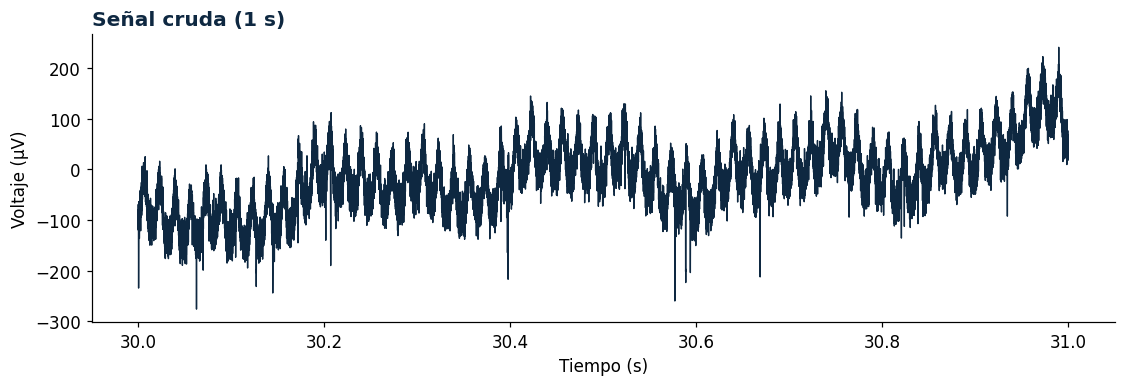

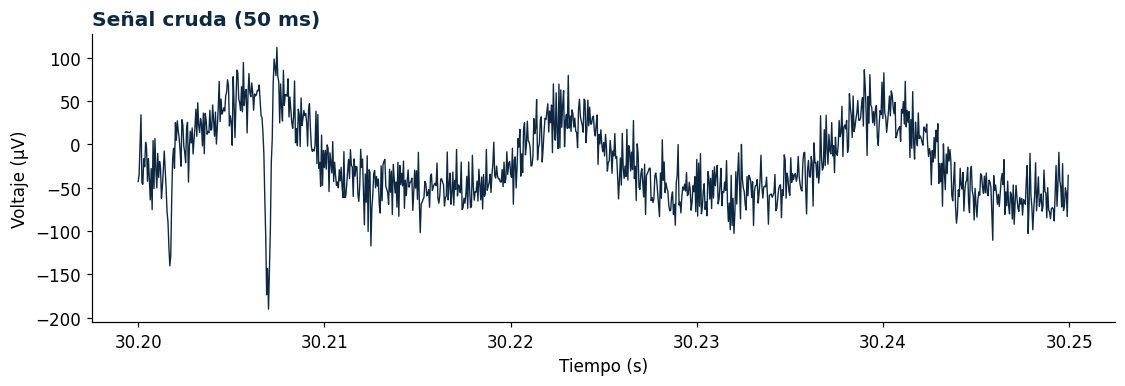

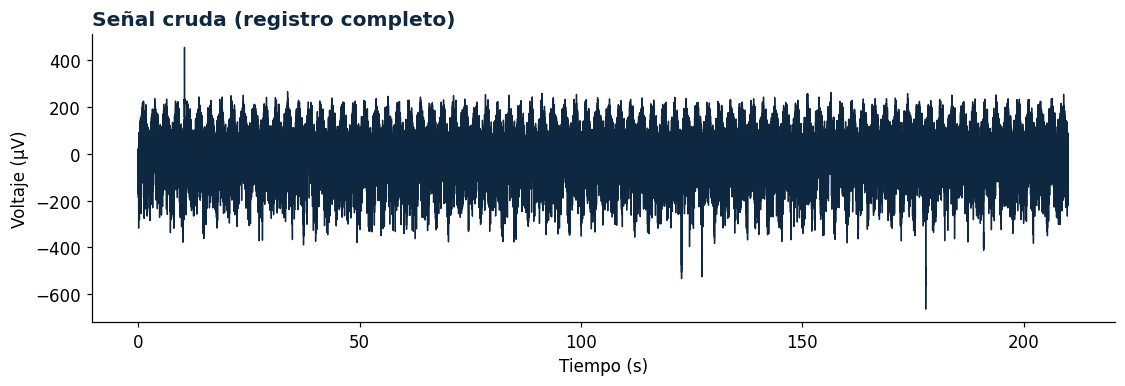

In [ ]:
def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""

    #Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES
    m = (t >= t0) & (t < t1)

    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)

    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("Tiempo (s)")
    plt.ylabel("Voltaje (µV)")


#Primer zoom: un segundo
ver(cruda, "Señal cruda (1 s)", t0=30.0, t1=31.0)

#Su código aquí: los otros dos zooms (50 ms y el registro completo)

#Segundo zoom: 50 ms dentro del mismo segundo
ver(cruda, "Señal cruda (50 ms)", t0=30.200, t1=30.250)

#Tercer zoom: registro completo
ver(cruda, "Señal cruda (registro completo)", t0=0.0, t1=210.0)

**Los tres problemas que encontramos:**

1. La señal no se mantiene alrededor de un nivel fijo, hay una especie de onda lenta sobre la que aparecen las fluctuaciones rápidas, es decir, la línea de base está oscilando/variando lentamente.

2. El comportamiento de la señal cambia a lo largo del registro; la amplitud y el nivel de la señal presentan variaciones en diferentes momentos del registro. Entonces no se podría asumir simplemente que toda la señal tiene exactamente las mismas características de principio a fin.

3. Hay algunos picos extremadamente grandes (tanto positivos como negativos) que sobresalen muchísimo de la actividad habitual.

**Pregunta B2.** *¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos en la Sesión 3?*

Los picos aislados y enormes son los que nos impiden contar los disparos a ojo, porque pueden ocultar o confundirse con los disparos reales.

---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt:_


> Tengo un array de voltaje en µV llamado cruda y su frecuencia de muestreo fs. Crea una función llamada espectro() para obtener y graficar el espectro de potencia de una señal. La función debe recibir la señal x, la frecuencia de muestreo fs, una etiqueta para el título y un valor fmax=500. Según la guía, el espectro debe calcularse usando scipy.signal.welch con nperseg=8192. La función debe devolver dos arrays: f, con las frecuencias en Hz, y P, con la potencia en cada frecuencia. En la gráfica muestra solo las frecuencias hasta fmax y usa plt.semilogy para que la potencia esté en escala logarítmica. Añade un título y labels de los ejes con sus unidades. Finalmente, aplica la función a la señal cruda y guarda los resultados en las variables f y P. Mantén el código sencillo, no uses librerías adicionales que no sean necesarias y explica con comentarios qué hace cada parte.

Pico dominante entre 40 y 200 Hz: 61.0 Hz


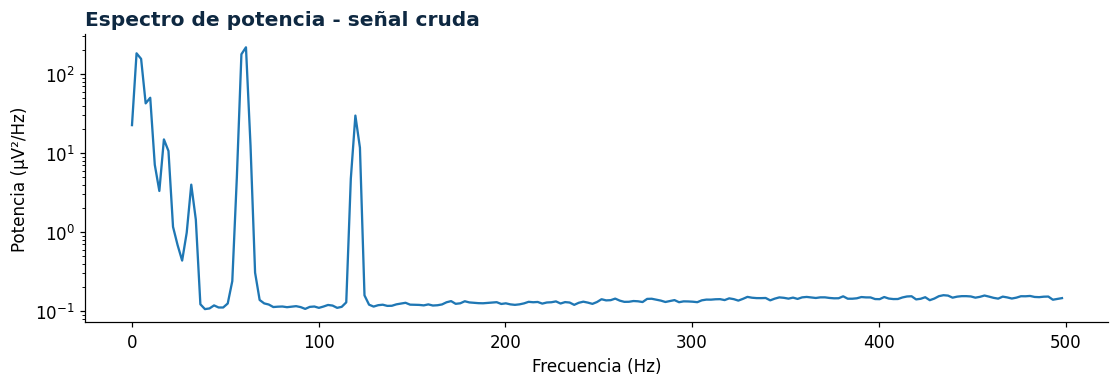

In [ ]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.

#Importa las librerías necesarias
import matplotlib.pyplot as plt
from scipy.signal import welch


# Crea una función para calcular y graficar el espectro de potencia
def espectro(x, fs, etiqueta, fmax=500):
    """Calcula y grafica el espectro de potencia de una señal."""

    # Calcula las frecuencias y la potencia usando el método de Welch
    f, P = welch(x, fs=fs, nperseg=8192)

    # Selecciona únicamente las frecuencias menores o iguales a fmax
    mascara = f <= fmax

    # Crea una figura nueva
    plt.figure()

    # Grafica la potencia en escala logarítmica
    plt.semilogy(f[mascara], P[mascara])

    # Agrega el título de la gráfica
    plt.title(etiqueta, color=NAVY, fontweight="bold", loc="left")

    # Agrega el nombre y las unidades del eje x
    plt.xlabel("Frecuencia (Hz)")

    # Agrega el nombre y las unidades del eje y
    plt.ylabel("Potencia (µV²/Hz)")

    # Devuelve los arrays completos de frecuencia y potencia
    return f, P


# Al final tienen que quedar definidas estas dos variables:

f, P = espectro(cruda, fs, "Espectro de potencia - señal cruda")      # llamen a su función aquí

# Esta línea dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

In [ ]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


**Pregunta C2.** Con números, no de memoria:

1. El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
2. Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
3. La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
4. ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.

_Escriban su respuesta aquí:_

1. La diferencia sí se explica porque la resolución del espectro es de 2.44Hz, lo que significa que las frecuencias se analizan en saltos de 2.44Hz y no una por una. Como 60Hz no cae exactamente en uno de esos puntos, el pico aparece en 61Hz, que es el valor más cercano.

2. Es un armónico que aparece cerca de 120Hz y viene del mismo ruido de la red eléctrica de 60Hz.

3. Con segmentos de 0.4096s no alcanza a caber un ciclo completo de la deriva, porque cada ciclo dura 2.5s, así que no se ve bien en el espectro. Al usar segmentos de 10s, sí aparece el pico cerca de 0.4Hz, pero quedan menos segmentos para promediar y el espectro se vuelve más irregular.

4. Se usa una escala logarítmica porque en el espectro hay valores de potencia muy diferentes entre sí. Con plt.plot, los picos grandes resaltan mucho y los valores pequeños quedan casi pegados al eje, por lo que se dejan de ver varios detalles del espectro.


_Escriban aquí su prompt:_


> Calcula la resolución del espectro usando f[1] - f[0], guarda el resultado en una variable llamada resolucion y muéstralo con print() indicando la unidad en Hz. Explica con comentarios sencillos qué hace cada línea.

> Calcula cuánto dura un segmento de Welch usando 8192/fs y cuánto dura un ciclo de la deriva de 0.4Hz usando 1/0.4, y muestra ambos resultados en segundos. Después vuelve a calcular el espectro de cruda con nperseg=200000, grafica únicamente las frecuencias menores de 1Hz con plt.semilogy y calcula cuánto dura ahora cada segmento. Coloca los ejes con sus unidades y explica con comentarios sencillos qué hace cada parte del código.

> Usando los mismos valores f y P del espectro que ya calculamos, selecciona las frecuencias hasta 500Hz y vuelve a graficarlas usando plt.plot en vez de plt.semilogy, para comparar cómo se ve el espectro con una escala normal en el eje y. Coloca los ejes con sus unidades, agrega un título sencillo y explica con comentarios qué hace cada parte del código.

Resolución del espectro: 2.44140625 Hz

Duración del segmento: 0.4096 s
Período de la deriva: 2.5 s
Duración del segmento largo: 10.0 s


Text(0.5, 1.0, 'Espectro de potencia - escala normal')

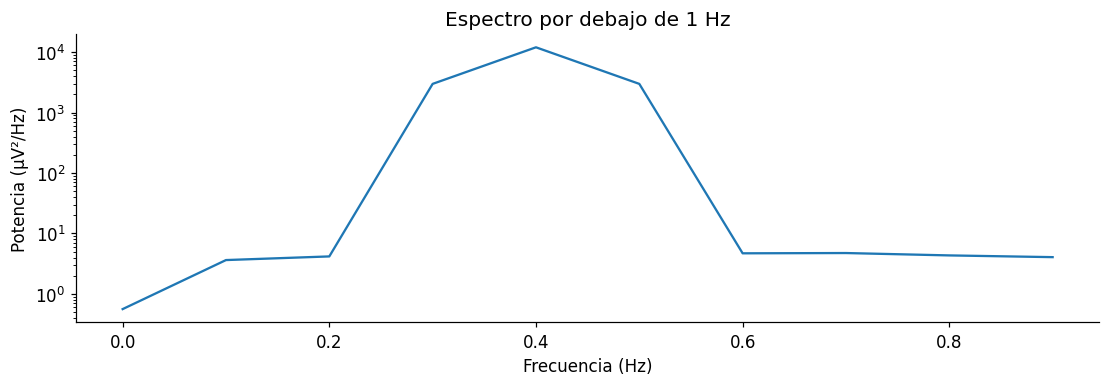

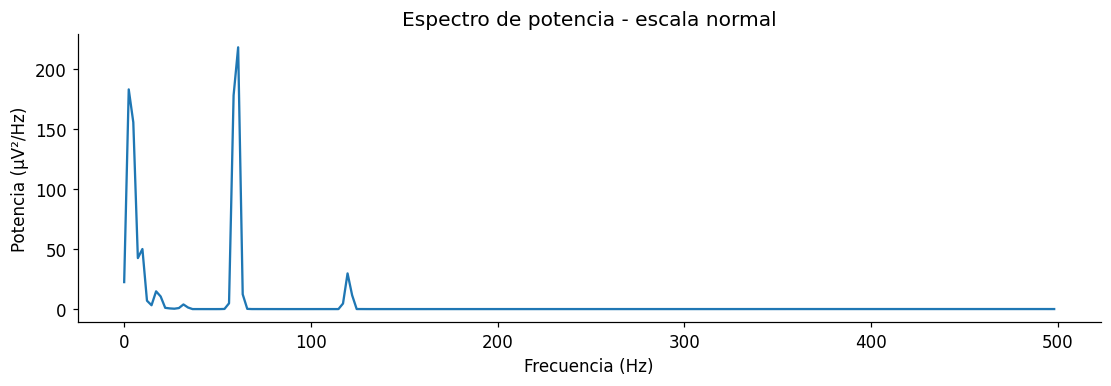

In [ ]:
resolucion = f[1] - f[0]
print("Resolución del espectro:", resolucion, "Hz")


#Calcula cuánto dura cada segmento que usa Welch
duracion_segmento = 8192 / fs

#Calcula cuánto dura un ciclo completo de una señal de 0.4 Hz
periodo_deriva = 1 / 0.4

#Muestra cuánto dura cada segmento
print("\nDuración del segmento:", duracion_segmento, "s")

#Muestra cuánto dura un ciclo de la deriva
print("Período de la deriva:", periodo_deriva, "s")


#Vuelve a calcular el espectro pero usando segmentos mucho más largos
f_largo, P_largo = welch(cruda, fs=fs, nperseg=200000)

#Selecciona solamente las frecuencias menores de 1 Hz
m = f_largo < 1

#Crea una nueva figura
plt.figure()

#Grafica solamente la parte del espectro que está por debajo de 1 Hz
plt.semilogy(f_largo[m], P_largo[m])

#Coloca el nombre y las unidades del eje x
plt.xlabel("Frecuencia (Hz)")

#Coloca el nombre y las unidades del eje y
plt.ylabel("Potencia (µV²/Hz)")

#Coloca un título a la gráfica
plt.title("Espectro por debajo de 1 Hz")

#Calcula cuánto dura un segmento cuando nperseg es 200000
duracion_segmento_largo = 200000 / fs

#Muestra esa duración.
print("Duración del segmento largo:", duracion_segmento_largo, "s")


#Selecciona las frecuencias hasta 500 Hz
m = f <= 500

#Crea una nueva figura
plt.figure()

#Grafica el espectro con una escala normal en el eje y
plt.plot(f[m], P[m])

#Agrega los nombres y unidades de los ejes
plt.xlabel("Frecuencia (Hz)")
plt.ylabel("Potencia (µV²/Hz)")

#Agrega un título
plt.title("Espectro de potencia - escala normal")

## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt:_
> Crea una sola función llamada filtrar() que sirva para distintos tipos de filtro. La función debe recibir la señal x, fs, baja=None, alta=None y orden=3, y devolver la señal filtrada con el mismo tamaño que la original. Según la guía, utiliza un filtro Butterworth: si solo se da alta, debe funcionar como pasa-bajos; si solo se da baja, como pasa-altos; y si se dan las dos, como pasa-banda. También debe usar fase cero con filtfilt o sosfiltfilt y las frecuencias deben normalizarse usando la frecuencia de Nyquist. Después utiliza la función para obtener la banda de potenciales de acción (AP) entre 300 y 5000 Hz a partir de la señal cruda y guarda el resultado en una variable llamada AP. Finalmente, grafica entre 30.0 y 31.0 s la señal cruda y la banda AP utilizando la función ver() que ya tenemos creada y siguiendo la plantilla adjunta. Mantén el código sencillo, no uses librerías adicionales que no sean necesarias y explica con comentarios qué hace cada parte.

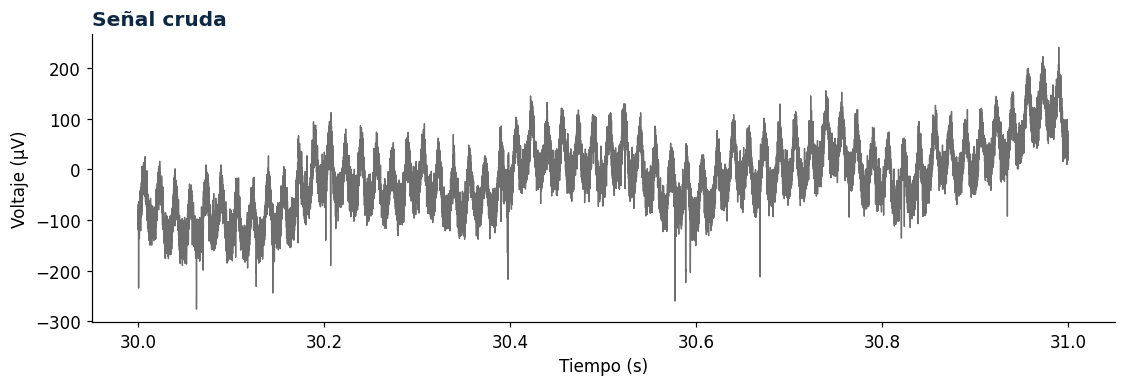

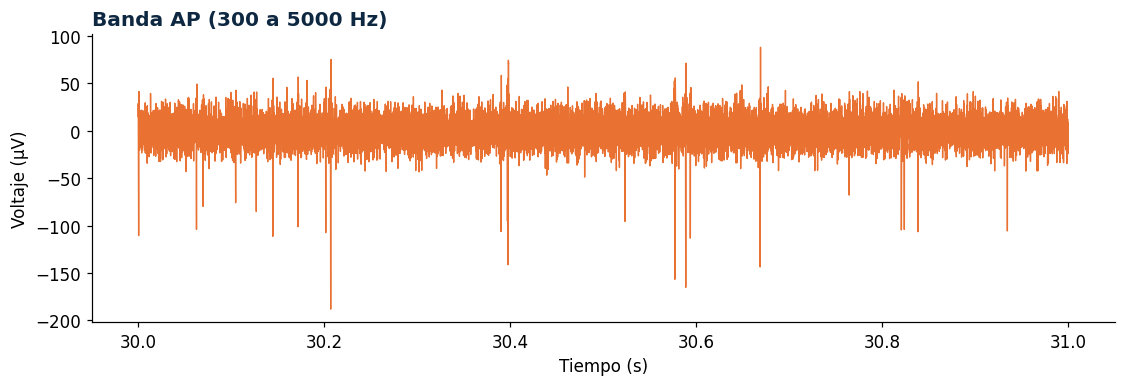

In [ ]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.

#Importa las funciones necesarias para crear y aplicar el filtro
from scipy.signal import butter, filtfilt


#Crea una función que puede funcionar como pasa-bajos, pasa-altos o pasa-banda
def filtrar(x, fs, baja=None, alta=None, orden=3):
    """Filtra una señal con un filtro Butterworth de fase cero."""

    #Calcula la frecuencia de Nyquist
    nyquist = fs / 2

    #Si se da baja y alta, crea un filtro pasa-banda
    if baja is not None and alta is not None:

        #Normaliza las dos frecuencias usando Nyquist
        frecuencias = [baja / nyquist, alta / nyquist]

        #Crea el filtro Butterworth pasa-banda
        b, a = butter(orden, frecuencias, btype="bandpass")

    #Si solo se da alta, crea un filtro pasa-bajos
    elif alta is not None:

        #Normaliza la frecuencia de corte
        frecuencia = alta / nyquist

        #Crea el filtro Butterworth pasa-bajos
        b, a = butter(orden, frecuencia, btype="lowpass")

    #Si solo se da baja, crea un filtro pasa-altos
    elif baja is not None:

        #Normaliza la frecuencia de corte
        frecuencia = baja / nyquist

        #Crea el filtro Butterworth pasa-altos
        b, a = butter(orden, frecuencia, btype="highpass")

    #Si no se da ninguna frecuencia, muestra un error
    else:
        raise ValueError("Debe indicar baja, alta o ambas.")

    #Aplica el filtro hacia adelante y hacia atrás para tener fase cero
    #La señal resultante conserva el mismo tamaño que la señal original
    filtrada = filtfilt(b, a, x)

    #Devuelve la señal filtrada
    return filtrada


# -------------------- BANDA DE POTENCIALES DE ACCIÓN --------------------

#Aplica un filtro pasa-banda entre 300 y 5000 Hz a la señal cruda
AP = filtrar(cruda, fs, baja=300, alta=5000)


# -------------------- GRÁFICAS --------------------

#Muestra 1 segundo de la señal cruda
ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)

#Muestra el mismo segundo después de filtrar la banda AP
ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

1. Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
2. ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?
3. Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

_Escriban su respuesta aquí:_

1. El ruido de la red está en 60Hz, mientras que los potenciales de acción están en frecuencias más altas desde 300Hz. Por eso el pasa-banda de 300–5000Hz elimina los 60Hz al mismo tiempo que conserva los disparos, así que no hace falta usar un filtro notch.

2. En el punto B observamos que la señal tenía una deriva lenta de la línea de base y también algunos picos aislados muy grandes. Al aplicar el filtro de la banda AP la deriva desaparece porque está en frecuencias bajas, mientras que los picos grandes se reducen aunque algunos pueden seguir apareciendo si tienen partes rápidas dentro de la banda de 300 a 5000Hz.

3. Haría falta un notch si queremos conservar una banda que sí incluye los 60Hz, por ejemplo el LFP, pero quitar específicamente el ruido de la red eléctrica; conviene quitar ese ruido para que no se confunda con lo que realmente queremos medir (el ruido de la red eléctrica vendría siendo el ruido instrumental o la interferencia). El notch elimina esa frecuencia sin eliminar todas las demás que están alrededor.

### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

> El código sí sirve porque al crear el filtro notch usa la frecuencia de muestreo fs y aplica filtfilt, como dice en las instrucciones. Solo sobra importar numpy porque no se utiliza, y fs ya estaba definido tampoco sería necesario volver a asignarlo.

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

<Figure size 1320x374 with 0 Axes>

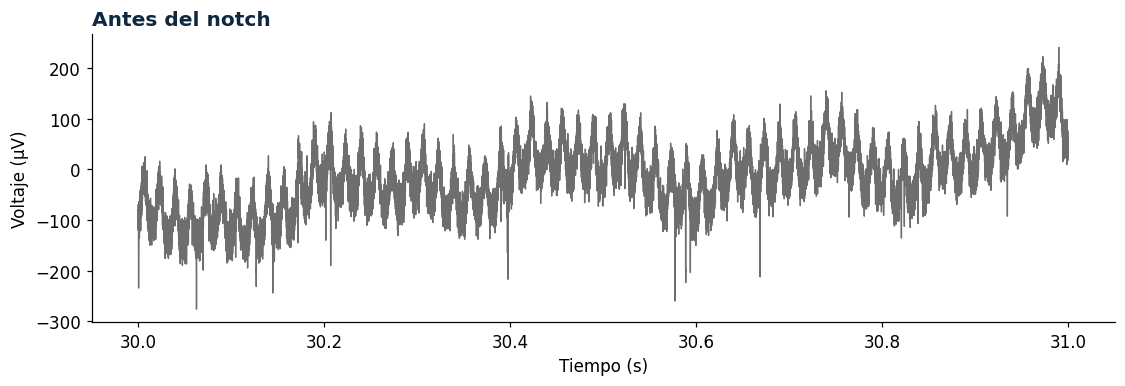

<Figure size 1320x374 with 0 Axes>

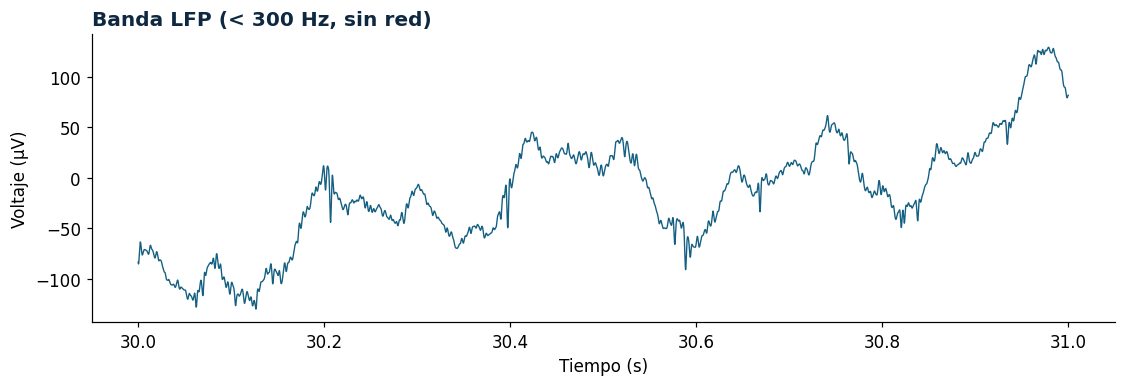

In [ ]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
# Ojo: son DOS frecuencias, 60 y 120 Hz.

#Importamos las funciones necesarias para crear y aplicar el filtro notch
from scipy.signal import iirnotch, filtfilt


def notch(x, f0, fs, Q=30):
    """Elimina una frecuencia específica de una señal."""

    #Diseña el filtro notch en la frecuencia que queremos eliminar
    b, a = iirnotch(f0, Q, fs=fs)

    #Aplica el filtro sin desplazar la señal en el tiempo
    x_filtrada = filtfilt(b, a, x)

    #Devuelve la señal filtrada
    return x_filtrada


#Quitamos primero los 60 Hz de la señal cruda
sin_60 = notch(cruda, 60, fs, Q=30)

#Quitamos después los 120 Hz y obtenemos la señal sin ruido de red
sin_red = notch(sin_60, 120, fs, Q=30)

#Aplicamos un pasa-bajos de 300 Hz para obtener la banda LFP
LFP = filtrar(sin_red, fs, alta=300)


#Comparamos la señal antes del notch y la banda LFP
plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP, "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)

In [ ]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

1. Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.
2. Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
3. Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

_Escriban su respuesta aquí:_

1. Al aplicar el notch en 9Hz, el LFP cambia porque se está eliminando una frecuencia que hace parte de esta señal. En las gráficas el cambio no es enorme, pero sí cambia la forma y la amplitud de algunas oscilaciones, lo que muestra que se perdió parte de la señal biológica.

2. Q controla qué tan ancha es la zona de frecuencias que elimina el notch. Con Q=2, el filtro es muy ancho y en el espectro se ve que no solo elimina los 60Hz, sino también muchas frecuencias cercanas por lo que se lleva parte de la señal que queríamos conservar.

3. Con 100Hz pasan más señales lentas y también puede pasar el ruido de 120Hz, por eso la señal se ve más mezclada. Con 800Hz, los disparos se siguen viendo pero cambian de forma y se hacen más pequeños. Por eso 300 Hz sirve como un punto medio porque quita buena parte de lo lento sin cambiar demasiado los disparos.

_Escriban aquí su prompt:_
> Usando la función notch() que ya tenemos creada, aplica un notch en 9Hz sobre la señal LFP y guarda el resultado en una nueva variable. Después grafica el LFP antes y después del notch usando la función ver(), en la misma ventana de 30.0 a 31.0s para poder comparar qué efecto tuvo eliminar esa frecuencia. Mantén el código sencillo y explica con comentarios qué hace cada parte.

> Usando la función notch() que ya tenemos creada, vuelve a aplicar el notch de 60Hz sobre la señal cruda, pero esta vez usando Q=2, y guarda el resultado en una nueva variable. Después calcula y grafica el espectro de potencia de esa señal usando la función espectro() que ya tenemos, mostrando las frecuencias hasta 500Hz. Explícame de manera sencilla qué controla el parámetro Q y comenta qué hace cada parte del código.

> Usando la función filtrar() que ya tenemos creada, repite el filtro pasa-banda de la señal cruda entre 100 y 5000Hz y entre 800 y 5000Hz, guardando los resultados en dos variables nuevas. Después grafica ambas señales en una ventana corta de tiempo para poder comparar claramente la forma de los disparos con la banda AP original de 300 a 5000Hz. Usa la función ver() que ya tenemos y explica con comentarios sencillos qué hace cada parte del código.

**¿Por qué el diagnóstico va antes del filtrado?**

> Porque primero hay que saber qué parte de la señal es ruido y qué parte queremos conservar, para escoger un filtro que quite lo necesario sin eliminar información útil.

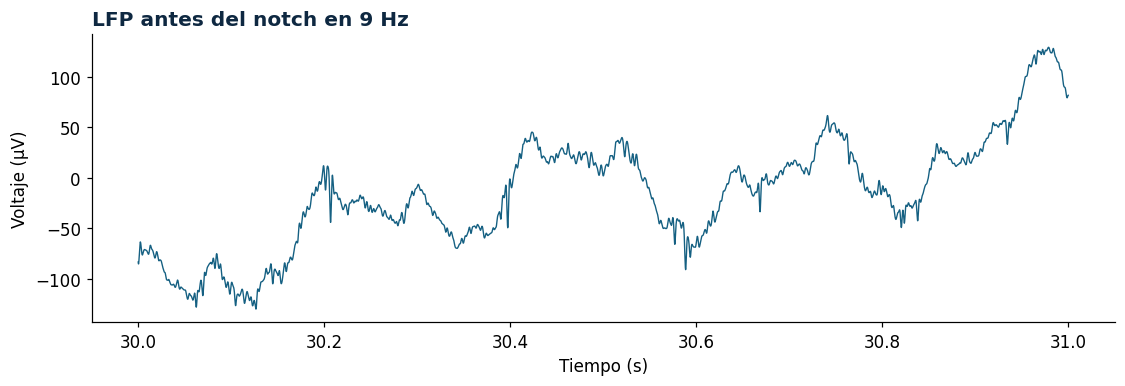

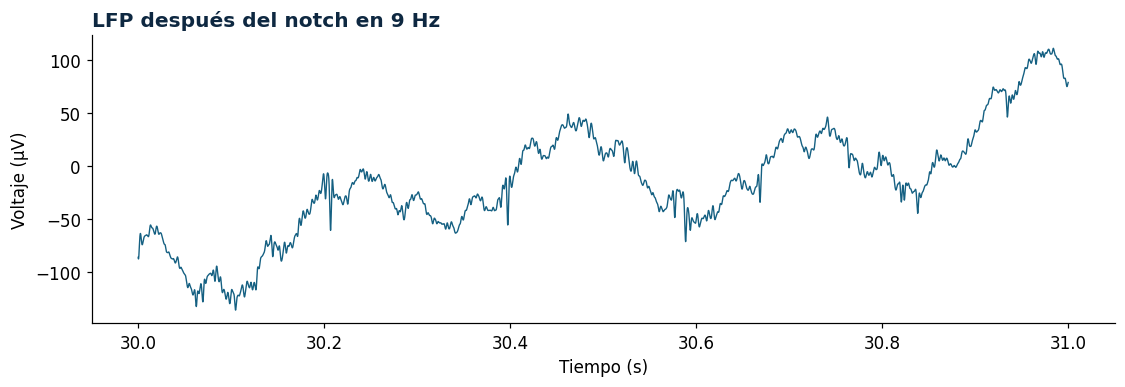

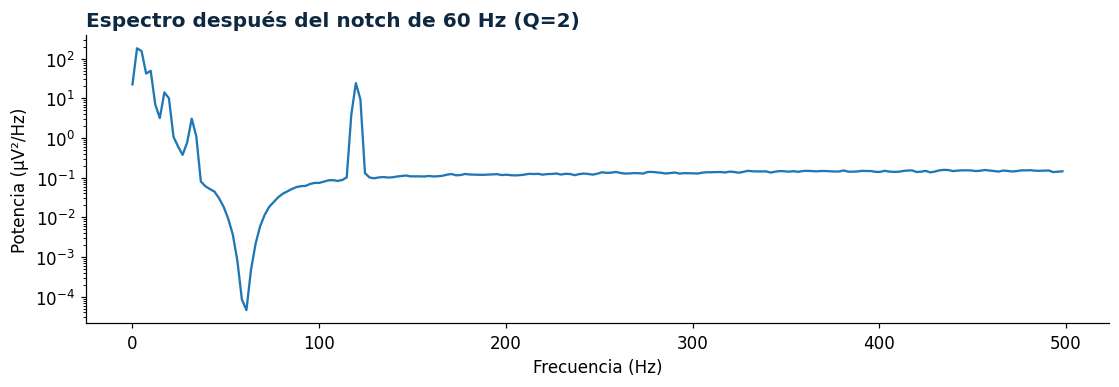

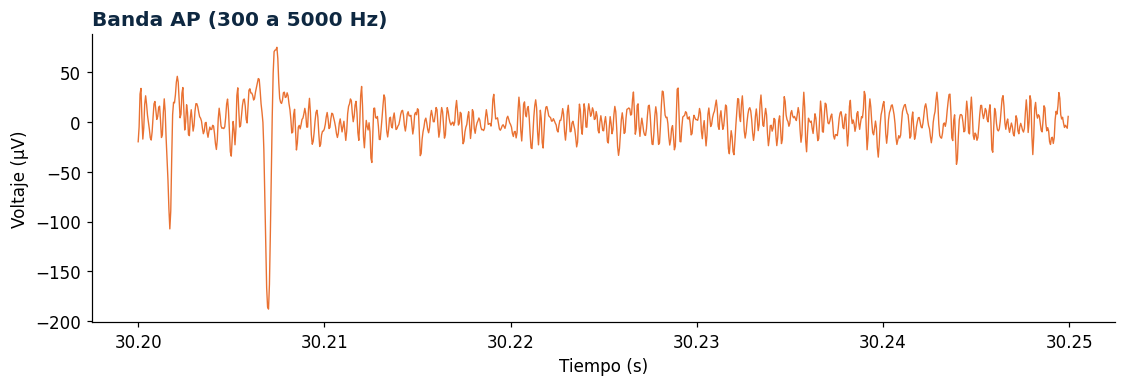

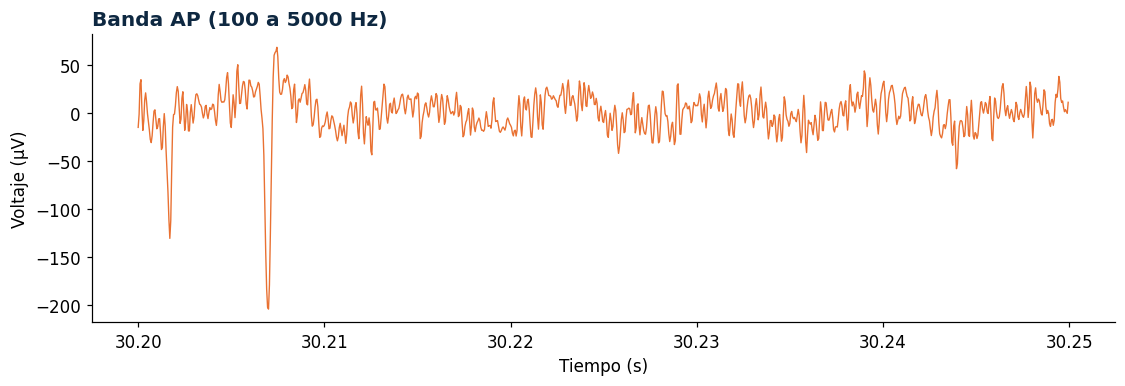

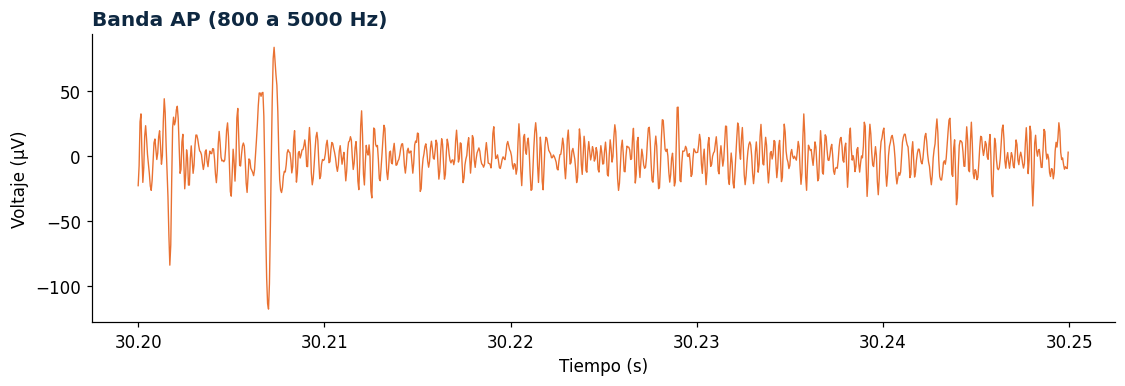

In [ ]:
#Aplica un notch en 9 Hz sobre la banda LFP
LFP_notch9 = notch(LFP, 9, fs, Q=30)

#Grafica el LFP antes del notch
ver(LFP, "LFP antes del notch en 9 Hz", t0=30.0, t1=31.0, color=TEAL)

#Grafica el LFP después del notch
ver(LFP_notch9, "LFP después del notch en 9 Hz", t0=30.0, t1=31.0, color=TEAL)



#Aplica un notch en 60 Hz, pero esta vez usando Q=2
sin_60_Q2 = notch(cruda, 60, fs, Q=2)

#Calcula y grafica el espectro de la señal después del notch
f_Q2, P_Q2 = espectro(
    sin_60_Q2,
    fs,
    "Espectro después del notch de 60 Hz (Q=2)",
    fmax=500
)


#Banda AP con el corte inferior en 100 Hz
AP_100 = filtrar(cruda, fs, baja=100, alta=5000)

#Banda AP con el corte inferior en 800 Hz
AP_800 = filtrar(cruda, fs, baja=800, alta=5000)


#Compara la banda AP original con las dos nuevas
ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.200, t1=30.250, color=ORANGE)

ver(AP_100, "Banda AP (100 a 5000 Hz)", t0=30.200, t1=30.250, color=ORANGE)

ver(AP_800, "Banda AP (800 a 5000 Hz)", t0=30.200, t1=30.250, color=ORANGE)

---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.



_Escriban aquí su prompt:_
> Completa la función detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) para encontrar los potenciales de acción en la señal AP. En esta señal los picos van hacia abajo, así que quiero detectar los que crucen un umbral negativo. Para calcular el umbral, primero estima el ruido usando la mediana del valor absoluto de la señal dividida entre 0.6745, y después usa -k veces ese valor como umbral. Si varias muestras seguidas corresponden al mismo disparo, deben contarse como un solo evento y se debe tomar la muestra más negativa. También quiero usar un tiempo muerto de 1.5ms para evitar contar varias veces el mismo disparo. La función debe devolver los índices de las muestras donde se detectaron los spikes. Adjunto una imagen con la plantilla que hay que completar, úsala como estructura y completa únicamente lo necesario. Mantén el código sencillo y explica con comentarios qué hace cada parte.

In [ ]:
def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    """Devuelve los índices de las muestras donde hay un potencial de acción."""

    #Estima el ruido de la señal
    sigma = np.median(np.abs(x)) / 0.6745

    #Calcula el umbral negativo para detectar los spikes hacia abajo
    umbral = -k * sigma

    #Busca qué muestras están por debajo del umbral
    debajo = x < umbral

    #Encuentra dónde comienza cada grupo de muestras bajo el umbral
    inicios = np.where(np.diff(debajo.astype(int)) == 1)[0] + 1

    #Encuentra dónde termina cada grupo
    finales = np.where(np.diff(debajo.astype(int)) == -1)[0] + 1

    #Corrige el caso en que la señal empiece debajo del umbral
    if debajo[0]:
        inicios = np.insert(inicios, 0, 0)

    #Corrige el caso en que la señal termine debajo del umbral
    if debajo[-1]:
        finales = np.append(finales, len(x))

    #Guarda un solo pico por cada grupo: el punto más negativo
    candidatos = []
    for inicio, final in zip(inicios, finales):
        pico = inicio + np.argmin(x[inicio:final])
        candidatos.append(pico)

    #Convierte el tiempo muerto de milisegundos a número de muestras
    muerto = int(muerto_ms * fs / 1000)

    #Guarda los spikes que respetan el tiempo muerto.
    indices = []

    for pico in candidatos:

        #Guarda siempre el primer spike
        if len(indices) == 0:
            indices.append(pico)

        #Si está suficientemente separado, guarda el nuevo spike
        elif pico - indices[-1] >= muerto:
            indices.append(pico)

        #Si está dentro del tiempo muerto, conserva el más negativo
        elif x[pico] < x[indices[-1]]:
            indices[-1] = pico

    #Devuelve los índices como enteros
    return np.array(indices, dtype=int)

    ...


indices = detectar_spikes(AP, fs)
tiempos = indices / fs                    # índices -> segundos
sigma   = np.median(np.abs(AP)) / 0.6745
umbral  = -4.5 * sigma

print(f"sigma del ruido ≈ {sigma:.1f} µV   ·   umbral = {umbral:.1f} µV")
print(f"detectados: {len(indices)} disparos en {len(AP)/fs:.0f} s "
      f"({len(indices)/(len(AP)/fs):.1f} por segundo)")

sigma del ruido ≈ 13.5 µV   ·   umbral = -60.9 µV
detectados: 5460 disparos en 210 s (26.0 por segundo)


In [ ]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

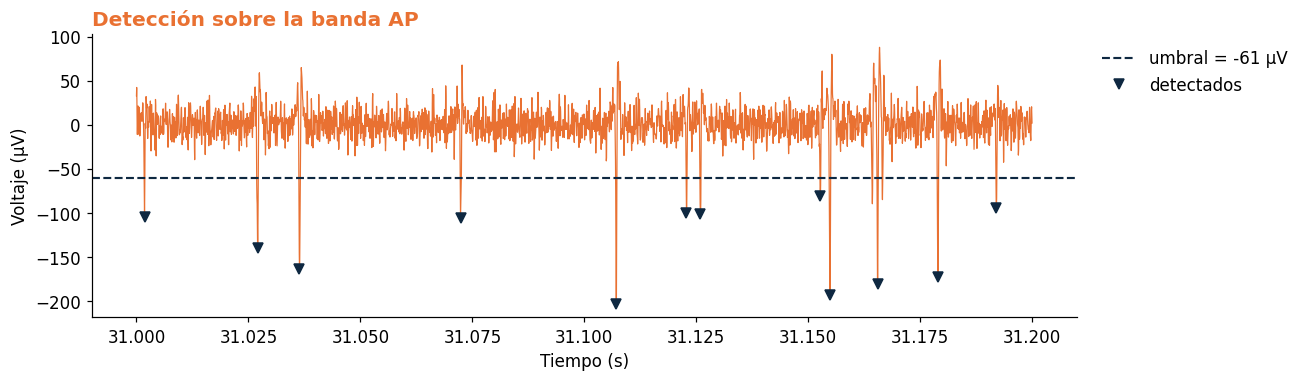

In [ ]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)
d = indices[(tiempos >= t0) & (tiempos < t1)]      # detecciones dentro de la ventana

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(t[d], AP[d], "v", color=NAVY, ms=7, ls="none", label="detectados")  # ¿tiempo y voltaje de qué?
plt.xlabel("Tiempo (s)"); plt.ylabel("Voltaje (µV)")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

**¿Tiempo y voltaje de qué?:**  Tiempo de los spikes detectados y el voltaje de estos

✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt:_

> Crea una función emparejar(detectados_s, reales_s, tol_ms=1.0) que compare los tiempos de los disparos detectados con los tiempos reales. Los tiempos ya vienen ordenados y están en segundos. La función debe devolver VP, FP y FN. Para considerar que una detección corresponde a un disparo real debe haber una tolerancia de 1ms, ya que no tienen que coincidir exactamente en el mismo instante. Además, cada disparo real solo puede emparejarse con una sola detección y no puede volver a usarse para otro acierto. En el código que ya tengo, los tiempos detectados están guardados en tiempos y los tiempos reales ya están guardados en una variable llamada reales. Después de crear la función, úsala con esas dos variables para obtener VP, FP y FN. Mantén el código sencillo y explica con comentarios qué hace cada parte.

In [ ]:
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso

reales = v.spikes_de_referencia()     # los tiempos en segundos

# Su código aquí:
#la función emparejar(), y con ella los tres números.
def emparejar(detectados_s, reales_s, tol_ms=1.0):
    """Devuelve verdaderos positivos (VP), falsos positivos (FP) y falsos negativos (FN)."""

    #tolerancia de milisegundos a segundos
    tol_s = tol_ms / 1000

    #contadores en cero
    VP = 0
    FP = 0
    FN = 0

    #Índices para recorrer las detecciones y los valores reales
    i = 0
    j = 0

    #Recorre las dos listas mientras queden elementos en ambas
    while i < len(detectados_s) and j < len(reales_s):

        #Si están a menos de la tolerancia, es un acierto
        if abs(detectados_s[i] - reales_s[j]) <= tol_s:
            VP += 1
            i += 1
            j += 1

        #Si la detección ocurrió demasiado antes, es un falso positivo
        elif detectados_s[i] < reales_s[j]:
            FP += 1
            i += 1

        #Si el disparo real quedó sin detectar, es un falso negativo
        else:
            FN += 1
            j += 1

    #Las detecciones que sobren son falsos positivos
    FP += len(detectados_s) - i

    #Los disparos reales que sobren son falsos negativos
    FN += len(reales_s) - j

    #Devuelve los tres valores
    return VP, FP, FN

VP, FP, FN = emparejar(tiempos, reales, tol_ms=1.0)
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 5456   FP = 4   FN = 167
precisión     = 0.999
exhaustividad = 0.970


In [ ]:
# ✅ VERIFICACIÓN
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         5460 spikes
  En realidad hay    5623
  Aciertos           5456   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   97.0%  ███████████████████████████·

  ▸ Detección correcta. Puedes seguir.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?


_Escriban aquí su prompt:_

> Usando las funciones detectar_spikes() y emparejar() que ya tenemos, prueba distintos valores de k entre 3 y 8, usando los valores enteros 3, 4, 5, 6, 7 y 8. Para cada valor de k, vuelve a detectar los disparos en AP, convierte los índices a tiempos en segundos y compáralos con reales para obtener VP, FP y FN. Con esos valores calcula la precisión, la exhaustividad y F1, y guarda cada resultado para poder compararlos. Al final, grafica las tres medidas en una misma figura en función de k, con una leyenda, título y nombres de los ejes. Mantén el código sencillo y explica con comentarios qué hace cada parte.

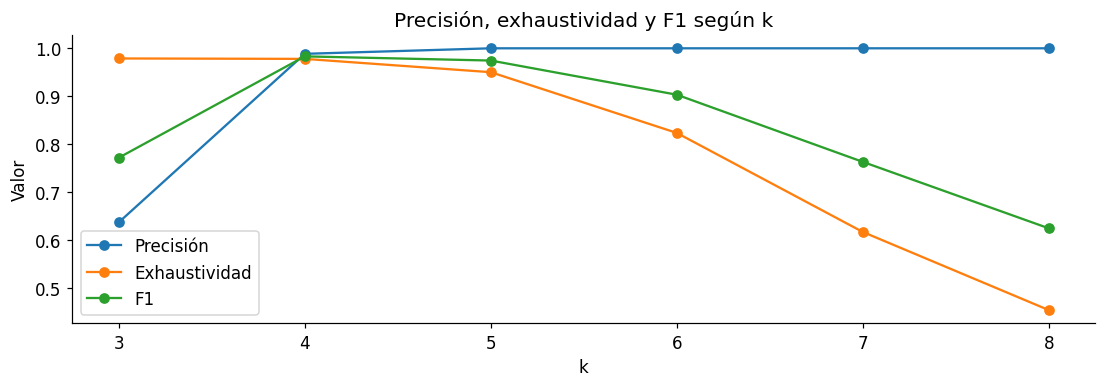

In [ ]:
valores_k = np.arange(3, 9)   #Crea los valores de k que vamos a probar: 3, 4, 5, 6, 7 y 8

#Crea listas vacías para guardar los resultados
precisiones = []
exhaustividades = []
f1_valores = []

#Repite el análisis para cada valor de k
for k in valores_k:

    indices_k = detectar_spikes(AP, fs, k=k)   #Detecta los disparos usando el valor actual de k

    tiempos_k = indices_k / fs   #Convierte los índices de las muestras a tiempos en segundos

    VP, FP, FN = emparejar(tiempos_k, reales)   #Compara los disparos detectados con los disparos reales

    precision = VP / (VP + FP)   #Calcula precisión

    exhaustividad = VP / (VP + FN)   #Calcula exhaustividad

    f1 = 2 * precision * exhaustividad / (precision + exhaustividad)   #Calcula F1, que combina precisión y exhaustividad

    #Guardar los resultados
    precisiones.append(precision)
    exhaustividades.append(exhaustividad)
    f1_valores.append(f1)


plt.figure()   #Crea una nueva figura

plt.plot(valores_k, precisiones, marker="o", label="Precisión")   #Grafica la precisión para cada valor de k

plt.plot(valores_k, exhaustividades, marker="o", label="Exhaustividad")   #Grafica la exhaustividad para cada valor de k

plt.plot(valores_k, f1_valores, marker="o", label="F1")   #Grafica F1 para cada valor de k

plt.xlabel("k")
plt.ylabel("Valor")

plt.title("Precisión, exhaustividad y F1 según k")

plt.legend()

**¿Qué valor de k elegirían y por qué?:** Elegiríamos k = 4 porque mantiene una precisión y una exhaustividad altas al mismo tiempo y tiene el mejor F1.

**¿Les duele más un disparo inventado o uno perdido?:** Preferiríamos evitar disparos inventados porque añadirían actividad que realmente no ocurrió.

### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

_Escriban aquí su prompt:_

> Usando las funciones detectar_spikes() y emparejar() que ya tenemos, la idea es analizar de dónde salen los falsos negativos. Primero usa los tiempos reales guardados en reales para calcular los intervalos entre disparos reales consecutivos y cuenta cuántos son menores de 1.5ms. Después compara la detección usando k=4 con dos períodos muertos diferentes: primero 1.5ms y luego 0.4ms. Para cada caso obtén VP, FP y FN y calcula la precisión y la exhaustividad. Mantén el mismo valor de k en los dos casos para comparar únicamente el efecto del período muerto. Muestra claramente los resultados y explica con comentarios sencillos qué hace cada parte del código.

In [ ]:
k_elegido = 4  #k para comparar solo el período muerto

intervalos = np.diff(reales)  #Calculamos los intervalos entre spikes reales
intervalos_cortos = np.sum(intervalos < 0.0015)  #Contamos los menores de 1.5ms

print("Intervalos reales menores de 1.5 ms:", intervalos_cortos)


indices_15 = detectar_spikes(AP, fs, k=k_elegido, muerto_ms=1.5)  #Detección con 1.5ms
tiempos_15 = indices_15 / fs  #Pasamos los índices a segundos
VP_15, FP_15, FN_15 = emparejar(tiempos_15, reales)  #Comparamos con los spikes reales

precision_15 = VP_15 / (VP_15 + FP_15)  #Precisión con 1.5ms
exhaustividad_15 = VP_15 / (VP_15 + FN_15)  #Exhaustividad con 1.5ms


indices_04 = detectar_spikes(AP, fs, k=k_elegido, muerto_ms=0.4)  #Detección con 0.4ms
tiempos_04 = indices_04 / fs  #Pasamos los índices a segundos
VP_04, FP_04, FN_04 = emparejar(tiempos_04, reales)  #Comparamos con los spikes reales

precision_04 = VP_04 / (VP_04 + FP_04)  #Precisión con 0.4 ms
exhaustividad_04 = VP_04 / (VP_04 + FN_04)  #Exhaustividad con 0.4ms


print("\nPeríodo muerto = 1.5 ms")
print("VP:", VP_15, "FP:", FP_15, "FN:", FN_15)
print("Precisión:", round(precision_15, 3))
print("Exhaustividad:", round(exhaustividad_15, 3))

print("\nPeríodo muerto = 0.4 ms")
print("VP:", VP_04, "FP:", FP_04, "FN:", FN_04)
print("Precisión:", round(precision_04, 3))
print("Exhaustividad:", round(exhaustividad_04, 3))

Intervalos reales menores de 1.5 ms: 122

Período muerto = 1.5 ms
VP: 5499 FP: 64 FN: 124
Precisión: 0.988
Exhaustividad: 0.978

Período muerto = 0.4 ms
VP: 5569 FP: 69 FN: 54
Precisión: 0.988
Exhaustividad: 0.99


**¿Sigue siendo válido descartar esos eventos?:** No porque el período refractario aplica a una sola neurona. Como aquí hay tres neuronas, dos pueden disparar casi al mismo tiempo y descartar uno de esos eventos haría que perdiéramos un disparo real.

**¿Qué ganaron y qué perdieron?:** Ganamos más disparos reales detectados poque los FN bajaron de 124 a 54 y la exhaustividad subió de 0.978 a 0.990. Perdimos un poco porque los FP subieron de 64 a 69, aunque la precisión prácticamente no cambió (0.988).

**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | 124 |
| intervalos reales más cortos que 1,5 ms | 122 |
| FN con período muerto de 0,4 ms | 54 |

**¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?**

> La mayoría de los falsos negativos se explican por el período muerto de 1,5 ms, porque había 122 disparos reales separados por menos de ese tiempo. Nos quedaríamos con 0,4ms porque reduce bastante los FN y mejora la exhaustividad, mientras que la precisión prácticamente no cambia.

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [ ]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

no, no las produjo la misma neurona porque en el grafico se ven amplitudes diferentes que van desde los -150 hasta los -400 microvoltios, lo que os dice que hay varias neuronas a diferentes distancias del electrodo

Matriz de formas construida: 5460 disparos × 40 muestras


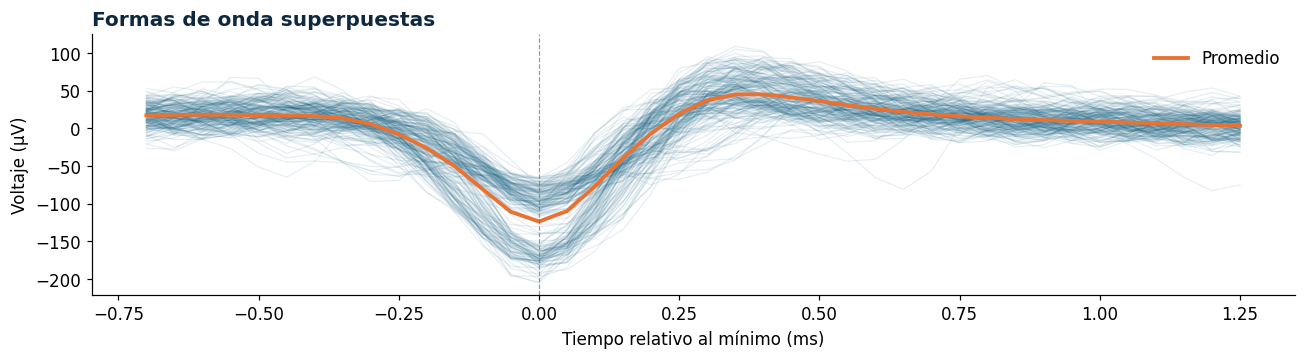

In [ ]:
#Definir la ventana en milisegundos y convertir a muestras
pre_ms = 0.7
post_ms = 1.3

n_pre = int(np.round(pre_ms * fs / 1000))    # Muestras antes del mínimo
n_post = int(np.round(post_ms * fs / 1000))  # Muestras después del mínimo
n_muestras = n_pre + n_post

# Eje temporal relativo
t_rel_ms = (np.arange(-n_pre, n_post) / fs) * 1000

#Filtrar índices en los bordes
mascara_bordes = (indices >= n_pre) & (indices < len(AP) - n_post)

indices = indices[mascara_bordes]
tiempos = tiempos[mascara_bordes]

#Construir la matriz (n_disparos x n_muestras)
lista_formas = [AP[idx - n_pre : idx + n_post] for idx in indices]
formas = np.array(lista_formas) # matriz n_disparos x n_muestras

#Graficar 200 formas y el promedio
plt.figure()

#Seleccionar hasta 200 formas aleatorias o las primeras 200
np.random.seed(42)
indices_submuestra = np.random.choice(len(formas), size=min(200, len(formas)), replace=False)

#Superposición de formas individuales
for idx in indices_submuestra:
    plt.plot(t_rel_ms, formas[idx], color=TEAL, alpha=0.1, lw=0.8)

#Forma de onda promedio
forma_promedio = np.mean(formas, axis=0)
plt.plot(t_rel_ms, forma_promedio, color=ORANGE, lw=2.5, label="Promedio")

#Configuración de ejes y títulos
plt.axvline(0, color=GRAY, ls="--", lw=0.8, alpha=0.7)
plt.title("Formas de onda superpuestas", color=NAVY, fontweight="bold", loc="left")
plt.xlabel("Tiempo relativo al mínimo (ms)")
plt.ylabel("Voltaje (µV)")
plt.legend(frameon=False)
plt.tight_layout()

print(f"Matriz de formas construida: {formas.shape[0]} disparos × {formas.shape[1]} muestras")

In [ ]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

Aprendí que para separar las neuronas no basta con la altura del disparo, así que extraje dos medidas de la onda: la amplitud (microvoltios) y el ancho del valle a media altura (ms), convirtiendo las muestras a milisegundos dividiendo entre la frecuencia de muestreo. Organicé las características en una matriz y las normalicé con Standard Scaler porque la amplitud opacaba al ancho y K-means habría ignorado la forma. Usé K = 3 porque sabemos que hay tres neuronas en el registro.

  Spikes tuyos emparejados con uno real: 5456
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2132       11        1
           2         55     1432       52
           0          0     1227      546

  Acierto   75.3%  █████████████████████·······

  ▸ Casi. Dos de tus unidades se están mezclando: mira la matriz
    y pregúntate qué característica NO estás usando.


np.float64(0.7532991202346041)

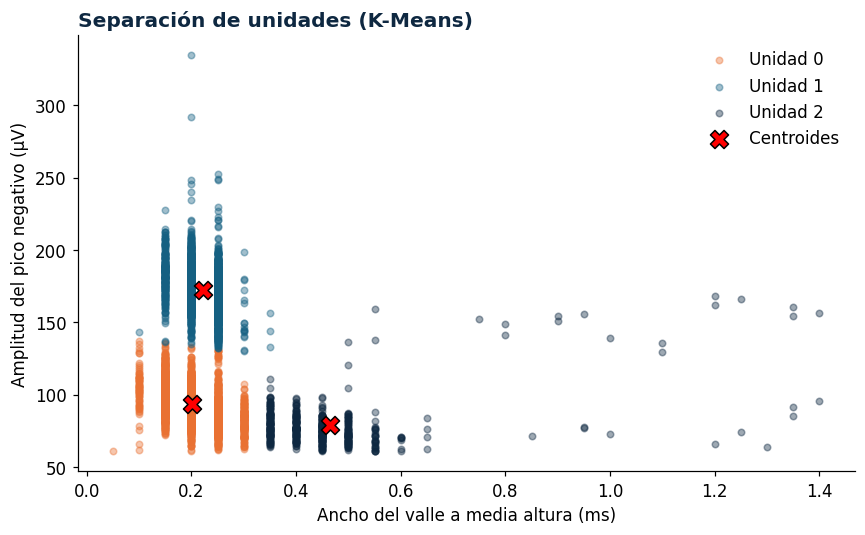

In [ ]:
# Su código aquí: características, gráfico de dispersión y agrupación.
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

#extracción de dos características por cada disparo

amplitudes = []
anchos_ms = []

for onda in formas:
    #c1: Amplitud del valle negativo
    pico_min = np.min(onda)
    amplitud = np.abs(pico_min)
    amplitudes.append(amplitud)

    #c2: Ancho del valle a media altura
    media_altura = pico_min / 2.0
    debajo = np.where(onda <= media_altura)[0]

    if len(debajo) >= 2:
        ancho_muestras = debajo[-1] - debajo[0]
    else:
        ancho_muestras = 1

    ancho_ms = (ancho_muestras / fs) * 1000.0
    anchos_ms.append(ancho_ms)

#organizar matriz X (n_disparos x 2)
X = np.column_stack((amplitudes, anchos_ms))


#normalización de características y K-Means (K = 3)

scaler = StandardScaler()
X_escalado = scaler.fit_transform(X)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
etiquetas = kmeans.fit_predict(X_escalado)  #identificador de unidad (0, 1, 2)

#centroides desescalados a unidades originales
centroides_orig = scaler.inverse_transform(kmeans.cluster_centers_)

#gráfico de dispersión

plt.figure(figsize=(8, 5))
colores_cluster = [ORANGE, TEAL, NAVY]

for k in range(3):
    m_k = etiquetas == k
    plt.scatter(
        X[m_k, 1],
        X[m_k, 0],
        color=colores_cluster[k],
        alpha=0.4,
        s=18,
        label=f"Unidad {k}",)

#graficar centroides
plt.scatter(
    centroides_orig[:, 1],
    centroides_orig[:, 0],
    color="red",
    marker="X",
    s=140,
    edgecolor="black",
    label="Centroides",)

plt.title(
    "Separación de unidades (K-Means)",
    color=NAVY,
    fontweight="bold",
    loc="left",
)
plt.xlabel("Ancho del valle a media altura (ms)")
plt.ylabel("Amplitud del pico negativo (µV)")
plt.legend(frameon=False, loc="upper right")
plt.tight_layout()

#agrupación usando únicamente la amplitud (1 sola característica)
X_amp = StandardScaler().fit_transform(np.array(amplitudes).reshape(-1, 1))
kmeans_amp = KMeans(n_clusters=3, random_state=42, n_init=10)
etiquetas_amp = kmeans_amp.fit_predict(X_amp)

#verificación pasando tiempos y etiquetas
v.verificar_unidades(tiempos, etiquetas_amp)



In [ ]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 5456
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2147       13        1
           0         21     2648      114
           2         19        9      484

  Acierto   96.8%  ███████████████████████████·

  ▸ Separación correcta.


### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?

Se confunden la Unidad 0 con la neurona real U3 ya que  porque comparten rangos de amplitud similares alrededor de 80 - 100 microvoltios, y la densidad de disparos de la U2 y la U0 se solapan un poco en el límite del espacio de características lo que hace que k-means clasifique algunos disparos de U3 dentro del grupo 0

- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que obtuvieron con dos características. ¿Cuánto ganaron con la segunda?


- ¿Qué característica les habría separado mejor las dos que se mezclan?

Al usar solo la amplitud el acierto fue del 75.3 %, mientras que al sumar el ancho del valle subió a 96.8 %, lo que nos dio una ganancia del 21.5 %. Esa segunda medida marcó toda la diferencia porque la Unidad 3 tenía voltajes casi iguales a los de la Unidad 2, así que sin el ancho de la onda las dos neuronas quedarian completamente mezcladas

El tiempo del pico positivo posterior o el ancho del valle a media altura, porque mide la duración temporal de la repolarización del potencial de acción y no solo el voltaje absoluto donde cae el mínimo

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | 75.3%|
| con las dos características que elegimos | 96.8%|

_Explicación: Usar solo la altura del pico no alcanza para separar bien las neuronas porque la Unidad 2 y la Unidad 3 tienen voltajes casi idénticos y terminan revolviéndose. Al meterle el ancho del valle como segunda característica, el algoritmo ya no solo mira qué tan profundo cae el disparo sino cuánto dura la onda, y permite diferenciar sin enredos esas dos neuronas y subir la precisión más de un 20 %._

---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

Violaciones globales (< 2 ms): 41 de 5459 (0.75%)
Unidad 1: 1 violaciones de 2785 (0.04%)
Unidad 2: 2 violaciones de 2160 (0.09%)
Unidad 3: 0 violaciones de 512 (0.00%)


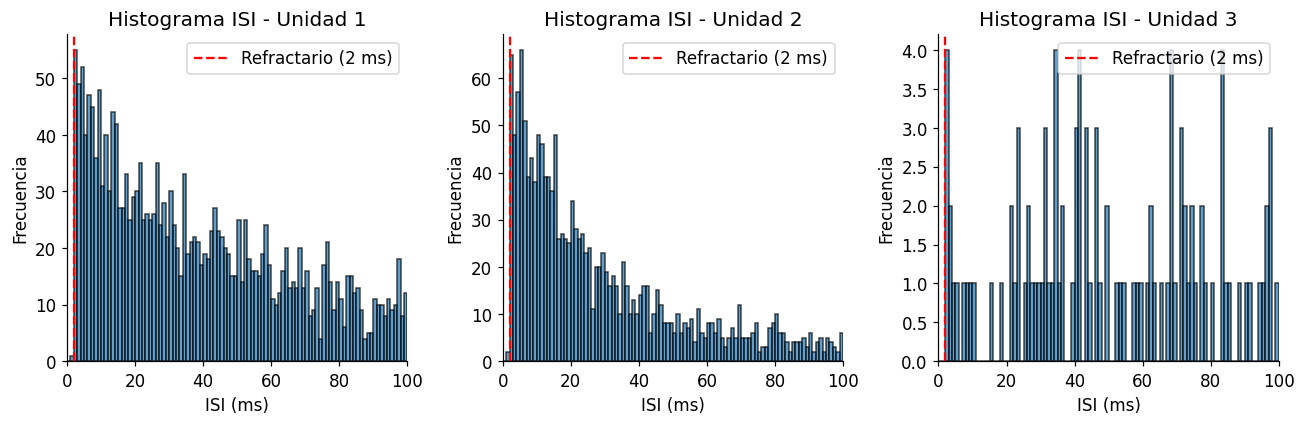

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#tiempos estén en milisegundos
tiempos_ms = tiempos * 1000.0 if np.max(tiempos) < 10000 else tiempos

#ISI Global
tiempos_ord = np.sort(tiempos_ms)
isi_global = np.diff(tiempos_ord)
viol_global = np.sum(isi_global < 2.0)
tasa_global = (viol_global / len(isi_global)) * 100

print(f"Violaciones globales (< 2 ms): {viol_global} de {len(isi_global)} ({tasa_global:.2f}%)")

#ISI por unidad
plt.figure(figsize=(12, 4))

for i, u in enumerate(np.unique(etiquetas)):
    # Filtrar tiempos de la unidad y ordenar
    tiempos_u = np.sort(tiempos_ms[etiquetas == u])
    isi_u = np.diff(tiempos_u)

    viol_u = np.sum(isi_u < 2.0)
    tasa_u = (viol_u / len(isi_u)) * 100 if len(isi_u) > 0 else 0

    # u + 1 para mostrar Unidad 1, Unidad 2, Unidad 3
    num_unidad = u + 1
    print(f"Unidad {num_unidad}: {viol_u} violaciones de {len(isi_u)} ({tasa_u:.2f}%)")

    # Graficar histograma
    plt.subplot(1, 3, i + 1)
    plt.hist(isi_u, bins=np.arange(0, 101, 1), edgecolor='black', alpha=0.7)
    plt.axvline(x=2.0, color='red', linestyle='--', linewidth=1.5, label='Refractario (2 ms)')
    plt.title(f'Histograma ISI - Unidad {num_unidad}')
    plt.xlabel('ISI (ms)')
    plt.ylabel('Frecuencia')
    plt.xlim(0, 100)
    plt.legend()

plt.tight_layout()
plt.show()

**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | 0.75% |
| unidad 1 | 0.04%|
| unidad 2 | 0.09%|
| unidad 3 | 0.00%|

¿Alguna unidad está contaminada? ¿Cuál y por qué?

No, ninguna. Todas tienen disparos repetidos por debajo del 0.1 %, muy lejos del límite del 0.5 % o 1 % que indicaría contaminación, asi que los tres grupos son neuronas distintas y bien separadas

¿Qué pasó al bajar el período muerto a 0,4 ms?

Aparecen lecturas falsas porque la ventana de silencio es muy corta. El detector se vuelve tan sensible que confunde el rebote de la misma onda con un segundo disparo, contando dos veces la misma señal

---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [ ]:
import h5py
import numpy as np

with h5py.File(ARCHIVO, "r") as f:
    inicios     = f["estimulos/tiempo_inicio_s"][:]
    condiciones = f["estimulos/condicion"][:]
    t_pre       = f["estimulos"].attrs["duracion_pre_s"]
    t_est       = f["estimulos"].attrs["duracion_estimulo_s"]
    t_post      = f["estimulos"].attrs["duracion_post_s"]

#cantidad de ensayos total y por condición
unicos, conteos = np.unique(condiciones, return_counts=True)
print(f"Total de ensayos: {len(condiciones)}")
for cond, cant in zip(unicos, conteos):
    c_nombre = cond.decode() if isinstance(cond, bytes) else cond
    print(f"  Condición {c_nombre}: {cant} ensayos")

#duración del ensayo e inicio del estímulo
duracion_total = t_pre + t_est + t_post
print(f"\nDuración total de un ensayo: {duracion_total:.1f} s")
print(f"El estímulo empieza a los {t_pre:.1f} s de iniciado el ensayo.")

#orden de las condiciones
cond_muestra = [c.decode() if isinstance(c, bytes) else c for c in condiciones[:10]]
print(f"\nSecuencia (primeros 10 ensayos): {cond_muestra}")

print("¿Están intercaladas y por qué importa?")


print("Las condiciones están intercaladas al azar.")
print("Importa para evitar la habituación o el cansancio de la neurona,")
print("asegurando que los cambios de disparo sean por el estímulo y no por el orden.")

Total de ensayos: 60
  Condición A: 20 ensayos
  Condición B: 20 ensayos
  Condición C: 20 ensayos

Duración total de un ensayo: 3.0 s
El estímulo empieza a los 1.0 s de iniciado el ensayo.

Secuencia (primeros 10 ensayos): ['B', 'B', 'C', 'A', 'A', 'A', 'C', 'A', 'C', 'B']
¿Están intercaladas y por qué importa?
Las condiciones están intercaladas al azar.
Importa para evitar la habituación o el cansancio de la neurona,
asegurando que los cambios de disparo sean por el estímulo y no por el orden.


In [ ]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

  OK    hay un inicio por ensayo y una condición por ensayo
  OK    las condiciones están intercaladas, no en bloques
  OK    el pre-estímulo y el estímulo son positivos y menores que el ensayo
  OK    los ensayos no se solapan


---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [ ]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""
    ensayos_alineados = []

    for inicio in inicios:
        #el estímulo empieza segundos después del inicio
        t_estimulo = inicio + t_pre

        #tiempos respecto al estímulo
        relativos = tiempos - t_estimulo

        #filtrar
        en_ventana = relativos[(relativos >= ventana[0]) & (relativos <= ventana[1])]
        ensayos_alineados.append(en_ventana)

    return ensayos_alineados

etiquetas = np.asarray(etiquetas)     #por si quedaron en una lista
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

In [ ]:
#comprobación
u_test = np.unique(etiquetas)[0]
i_ensayo = 0

#instante exacto en que empieza el estímulo
t_est_manual = inicios[i_ensayo] + t_pre

#restar el instante del estímulo a todos los disparos de esa unidad
tiempos_u = tiempos[etiquetas == u_test]
relativos_manual = tiempos_u - t_est_manual

#filtrar en la ventana (-1.0 a 2.0 s)
manual = relativos_manual[(relativos_manual >= -1.0) & (relativos_manual <= 2.0)]

#comparar con lo que devuelve la función alinear()
desde_funcion = alineados[u_test][i_ensayo]

print(f"Calculados a mano (primeros 5): {np.round(manual[:5], 4)}")
print(f"Desde la función   (primeros 5): {np.round(desde_funcion[:5], 4)}")
print(f"¿Coinciden exactamente?: {np.allclose(manual, desde_funcion)}")

Calculados a mano (primeros 5): [-0.9995 -0.9373 -0.9302 -0.8952 -0.873 ]
Desde la función   (primeros 5): [-0.9995 -0.9373 -0.9302 -0.8952 -0.873 ]
¿Coinciden exactamente?: True


In [ ]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

  OK    hay una lista de disparos por ensayo
  OK    todos los tiempos caen dentro de la ventana pedida
  OK    hay disparos antes del estímulo (tiempos negativos)
  OK    la ventana está completa en todos los ensayos


---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
- ¿Alguna responde solo a una de las tres condiciones?
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

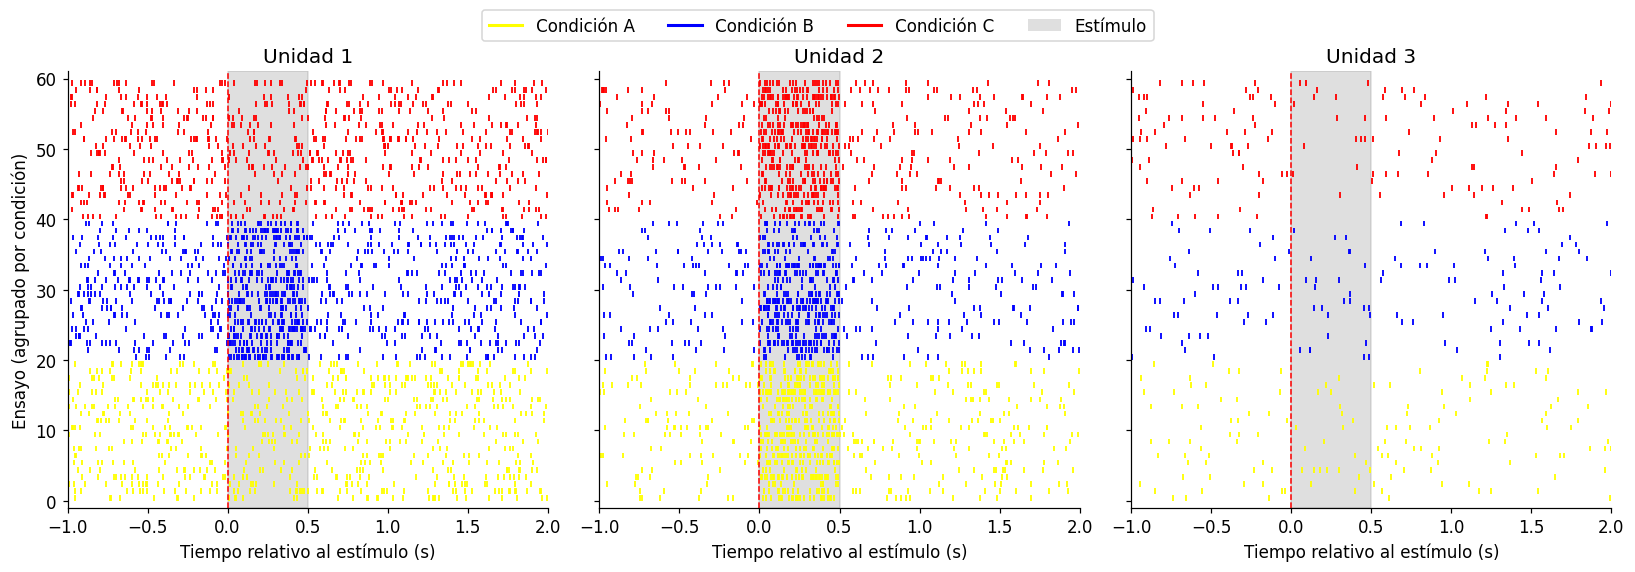

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

#definir colores para cada condición (A, B, C)
colores_cond = {'A': 'yellow', 'B': 'blue', 'C': 'red'}

#crear figura con 3 subplots (uno por unidad)
fig, axes = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

#ordenar los ensayos agrupando por condición para visualizarlos en bloques
orden_ensayos = np.argsort(condiciones)
condiciones_ord = condiciones[orden_ensayos]

for idx_u, u in enumerate(np.unique(etiquetas)):
    ax = axes[idx_u]
    num_unidad = u + 1

    # Graficar disparo por disparo para cada ensayo
    for fila_nueva, idx_ensayo_orig in enumerate(orden_ensayos):
        disparos = alineados[u][idx_ensayo_orig]
        cond = condiciones_ord[fila_nueva]
        c_nombre = cond.decode() if isinstance(cond, bytes) else cond

        # Graficar cada evento como una marca vertical
        ax.vlines(disparos, ymin=fila_nueva, ymax=fila_nueva + 0.8,
                  color=colores_cond.get(c_nombre, 'black'), linewidth=1.2)

    #sombrear la ventana en que estuvo presente el estímulo
    ax.axvspan(0, t_est, color='gray', alpha=0.25, label='Estímulo')

    #línea vertical en t = 0 (inicio del estímulo)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)

    ax.set_title(f'Unidad {num_unidad}')
    ax.set_xlabel('Tiempo relativo al estímulo (s)')
    ax.set_xlim(-1.0, 2.0)
    ax.set_ylim(-1, len(condiciones) + 1)

    if idx_u == 0:
        ax.set_ylabel('Ensayo (agrupado por condición)')

#leyenda personalizada para las condiciones
handles = [plt.Line2D([0], [0], color=col, lw=2, label=f'Condición {cond}')
           for cond, col in colores_cond.items()]
handles.append(plt.Rectangle((0, 0), 1, 1, fc='gray', alpha=0.25, label='Estímulo'))
fig.legend(handles=handles, loc='upper center', bbox_to_anchor=(0.5, 1.05), ncol=4)

plt.tight_layout()
plt.show()

**Lo que leemos en el raster:**

1.   Las Unidades 1 y 2 sí reaccionan al estímulo (se ven muy tupidas de puntos entre 0.0 y 0.5 s), mientras que la Unidad 3 no responde y se queda igual todo el tiempo.

2.  La Unidad 1 solo se activa con la Condición B (naranja), mientras que la Unidad 2 responde a las tres condiciones, pero dispara mucho más fuerte con la C (verde) y la A (azul).



---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?

In [ ]:
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """Devuelve (centros_de_bin, tasa_en_Hz)."""
    bordes = np.arange(ventana[0], ventana[1] + ancho_bin_s, ancho_bin_s)
    # Juntamos los disparos de todos los ensayos en un solo arreglo
    todos_los_disparos = np.concatenate(ensayos_alineados)
    # Contamos cuantos disparos caen en cada bien
    cuentas_disparos, _ = np.histogram(todos_los_disparos, bins=bordes)
    # Centro de cada bin, punto medio entre el borde izquierdo y derecho
    centros = bordes[:-1] + ancho_bin_s / 2
    # se convierten las cuentas en tasa en Hz
    n_ensayos = len(ensayos_alineados)
    tasa_hz = cuentas_disparos / (n_ensayos * ancho_bin_s)

    return centros, tasa_hz

    ...

In [ ]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

  OK    devuelve dos arrays del mismo tamaño
  OK    hay 150 bins de 20 ms en una ventana de 3 s
  OK    los centros de bin están dentro de la ventana
  OK    la tasa está en Hz, no en disparos por bin


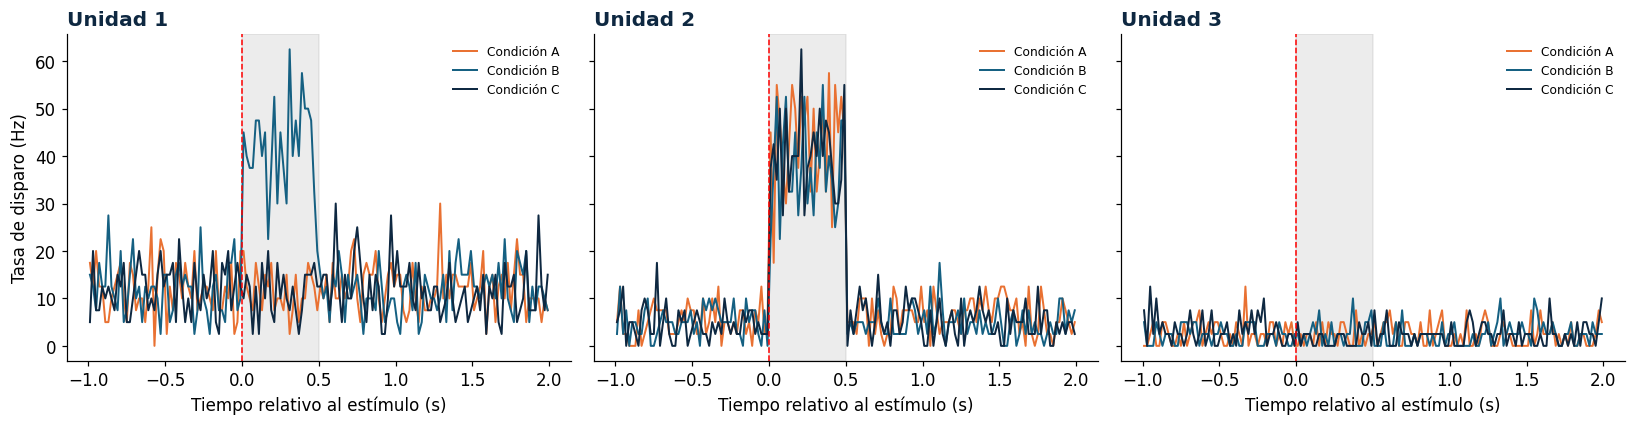

In [ ]:
#decodificamos las coniciones una sola vez (por si vienen como bytes desde HDF5)
condiciones_str = np.array([c.decode() if isinstance(c, bytes) else c for c in condiciones])
condiciones_unicas = sorted(set(condiciones_str))

#un color por condicion
colores_cond = {condiciones_unicas[0]: ORANGE,
                condiciones_unicas[1]: TEAL,
                condiciones_unicas[2]: NAVY}

ancho_bin_m2 = 0.02 #20ms
ventana = (-1.0, 2.0)

fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

for idx_u, u in enumerate(np.unique(etiquetas)):
    ax = axes[idx_u]

    for cond in condiciones_unicas:
        # Índices de los ensayos que tuvieron esta condición
        idx_ensayos_cond = np.where(condiciones_str == cond)[0]

        # Lista de disparos alineados (de esta unidad) solo para esos ensayos
        ensayos_cond = [alineados[u][i] for i in idx_ensayos_cond]

        # Calculamos el PSTH usando solo esos ensayos
        centros, tasa = psth(ensayos_cond, ventana, ancho_bin_m2)

        ax.plot(centros, tasa, color=colores_cond[cond], label=f"Condición {cond}", lw=1.3)

    # Marcamos la ventana del estímulo y el instante t=0
    ax.axvspan(0, t_est, color="gray", alpha=0.15)
    ax.axvline(0, color="red", ls="--", lw=1)

    ax.set_title(f"Unidad {u + 1}", color=NAVY, fontweight="bold", loc="left")
    ax.set_xlabel("Tiempo relativo al estímulo (s)")
    if idx_u == 0:
        ax.set_ylabel("Tasa de disparo (Hz)")
    ax.legend(frameon=False, fontsize=8)

plt.tight_layout()


bin =   5 ms  ->  pico = 46.7 Hz
bin =  20 ms  ->  pico = 27.5 Hz
bin =  50 ms  ->  pico = 27.3 Hz
bin = 200 ms  ->  pico = 21.4 Hz


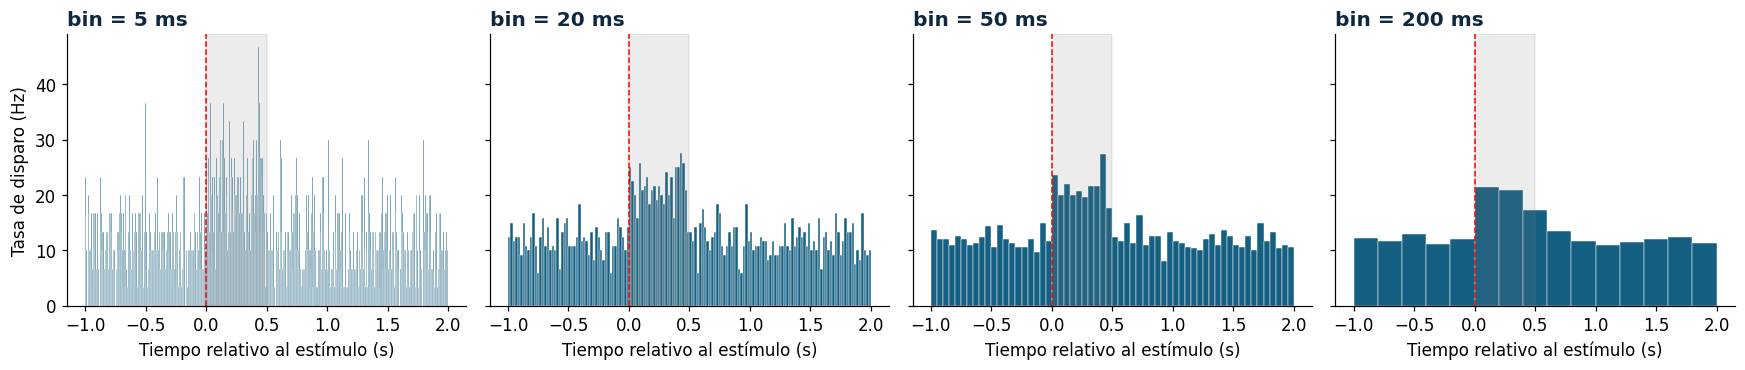

In [ ]:
u_responde = 0   # <-- (0, 1 o 2) de la unidad que sí respondía al estímulo

anchos_bin = [0.005, 0.020, 0.050, 0.200]   # 5, 20, 50 y 200 ms
ventana = (-1.0, 2.0)

fig, axes = plt.subplots(1, 4, figsize=(16, 3.5), sharey=True)

for ax, ancho in zip(axes, anchos_bin):
    centros, tasa = psth(alineados[u_responde], ventana, ancho)

    ax.bar(centros, tasa, width=ancho, color=TEAL, edgecolor="white", linewidth=0.3)

    ax.axvspan(0, t_est, color="gray", alpha=0.15)   #ventana del estímulo
    ax.axvline(0, color="red", ls="--", lw=1)         #instante del estímulo

    ax.set_title(f"bin = {ancho*1000:.0f} ms", color=NAVY, fontweight="bold", loc="left")
    ax.set_xlabel("Tiempo relativo al estímulo (s)")

axes[0].set_ylabel("Tasa de disparo (Hz)")
plt.tight_layout()

#Pico de tasa observado en cada panel, para completar la tabla de la celda de texto
for ancho in anchos_bin:
    centros, tasa = psth(alineados[u_responde], ventana, ancho)
    print(f"bin = {ancho*1000:>3.0f} ms  ->  pico = {tasa.max():.1f} Hz")

**Nuestra elección de bin y por qué:**

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | | |
| 20 ms | | |
| 50 ms | | |
| 200 ms | | |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

Si. Se puede leer U1 responde principalmente a B, U2 responde a A,B y C, y U3 no muestra una respuesta clara al estimulo.

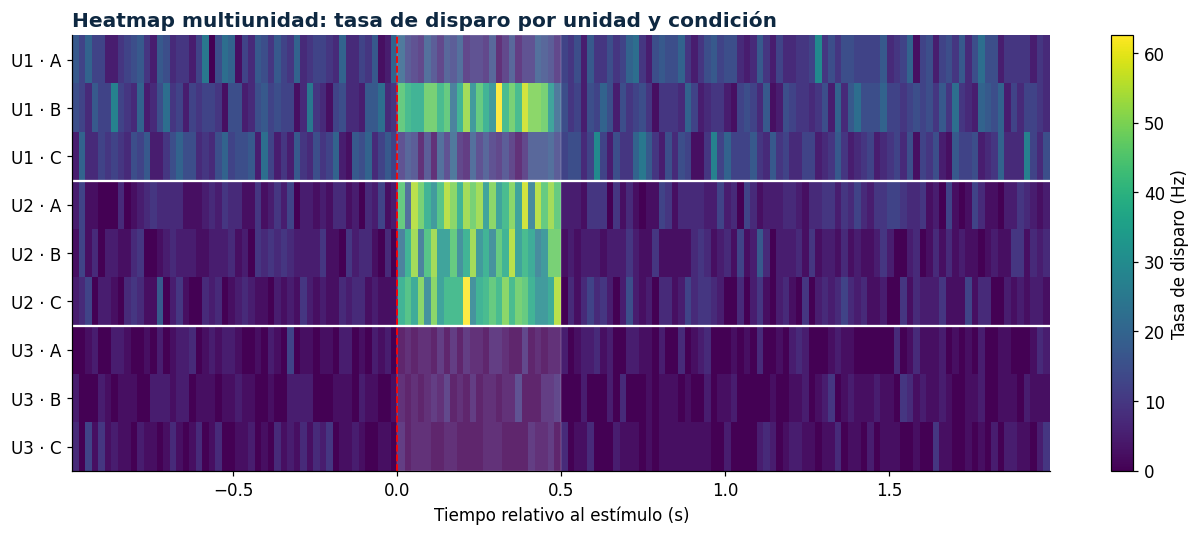

In [ ]:
ancho_bin_n = 0.02   #mismo bin que usamos en M2, 20 ms

condiciones_str = np.array([c.decode() if isinstance(c, bytes) else c for c in condiciones])
condiciones_unicas = sorted(set(condiciones_str))
unidades_unicas = np.unique(etiquetas)

#construimos una matriz: filas = (unidad, condición), columnas = bins de tiempo
filas_tasa = []
etiquetas_filas = []

for u in unidades_unicas:
    for cond in condiciones_unicas:
        idx_ensayos_cond = np.where(condiciones_str == cond)[0]
        ensayos_cond = [alineados[u][i] for i in idx_ensayos_cond]

        centros, tasa = psth(ensayos_cond, ventana, ancho_bin_n)
        filas_tasa.append(tasa)
        etiquetas_filas.append(f"U{u+1} · {cond}")

matriz = np.array(filas_tasa)   # forma: (9, n_bins)

#escala de color compartida (permite comparar unidades entre sí)
vmin, vmax = matriz.min(), matriz.max()

fig, ax = plt.subplots(figsize=(12, 5))

im = ax.imshow(matriz, aspect="auto", cmap="viridis", vmin=vmin, vmax=vmax,
               extent=[centros[0], centros[-1], len(etiquetas_filas), 0])

#barra de color con su unidad
cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Tasa de disparo (Hz)")

#línea en t=0 y ventana del estímulo marcadas
ax.axvline(0, color="red", ls="--", lw=1.2)
ax.axvspan(0, t_est, color="white", alpha=0.15)

ax.set_yticks(np.arange(len(etiquetas_filas)) + 0.5)
ax.set_yticklabels(etiquetas_filas)
ax.set_xlabel("Tiempo relativo al estímulo (s)")
ax.set_title("Heatmap multiunidad: tasa de disparo por unidad y condición",
             color=NAVY, fontweight="bold", loc="left")

#líneas horizontales para separar visualmente cada unidad (bloques de 3 filas)
for i in range(1, len(unidades_unicas)):
    ax.axhline(i * len(condiciones_unicas), color="white", lw=1.5)

plt.tight_layout()

**Lo que el heatmap muestra y el PSTH escondía:**

El PSTH mostraba cada unidad en un panel separado, asi que comparar la magnitud de la respuesta entre unidades dependia de mirar ejes distintos uno al lado del otro. Por otro lado, el heatmap junta las nueve combinaciones de uniadad y condicion en una sola figura con la misma escala de color, y eso deja ver de un solo vistazo que U2 responde mas fuerte, que U1 solo se activa con la condicion B y no con la A o C, y que U3 se mantiene completamente plana a sus tres filas durante todo el registro.

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

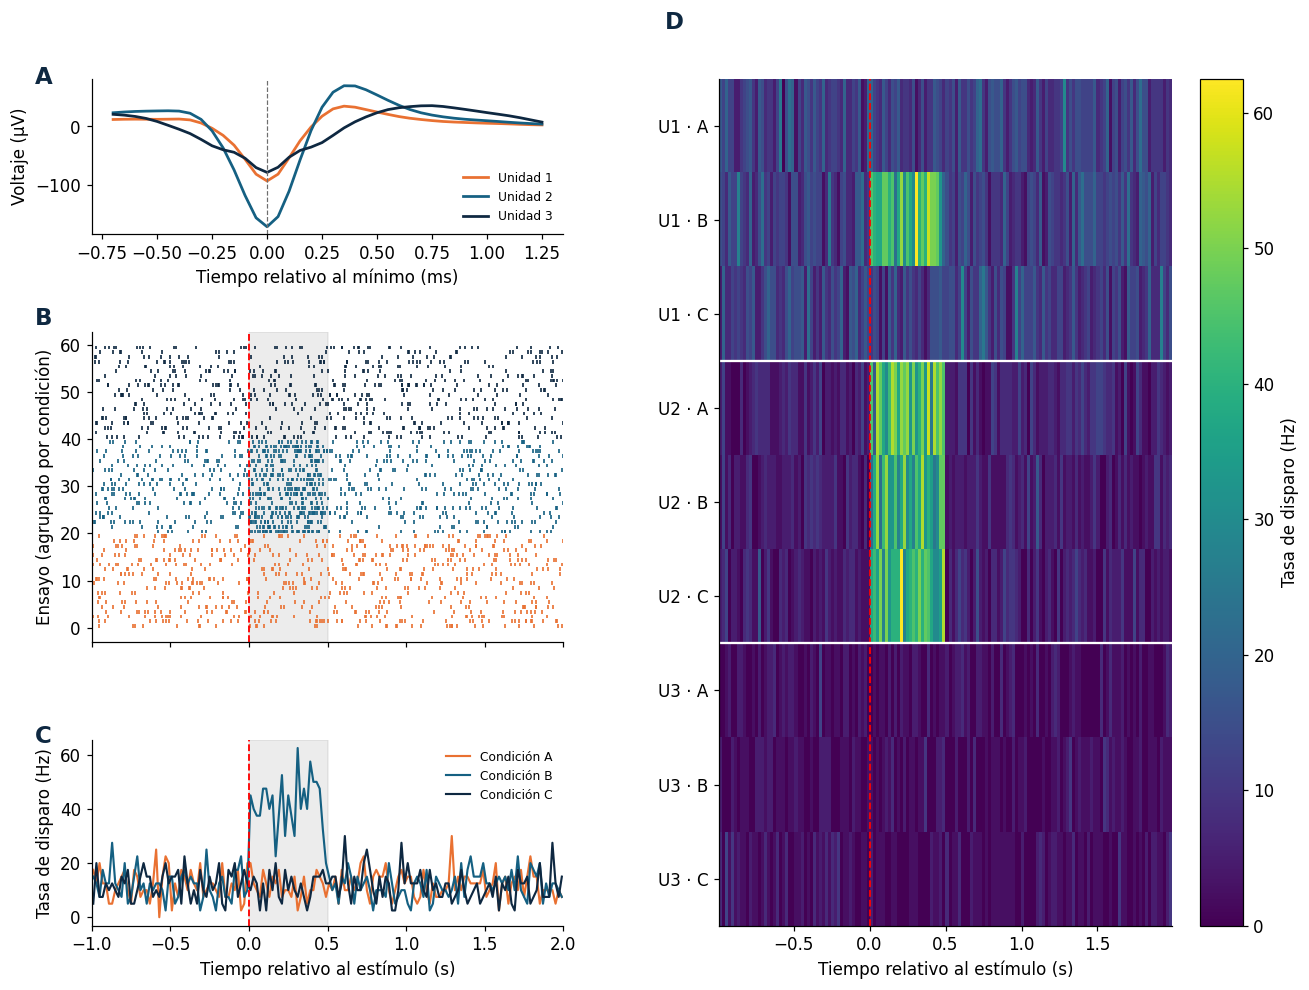

In [ ]:
u_responde = 0    # <-- misma unidad que usaste en M3 (la que responde al estímulo)
ventana = (-1.0, 2.0)
ancho_bin = 0.02  # 20 ms, consistente con M2 y N1

condiciones_str = np.array([c.decode() if isinstance(c, bytes) else c for c in condiciones])
condiciones_unicas = sorted(set(condiciones_str))
unidades_unicas = np.unique(etiquetas)
colores_cluster = [ORANGE, TEAL, NAVY]                      # un color fijo por unidad
colores_cond = {condiciones_unicas[0]: ORANGE,
                condiciones_unicas[1]: TEAL,
                condiciones_unicas[2]: NAVY}                 # un color fijo por condición

# ---- Layout: 3 filas x 2 columnas. B y C comparten el eje x (columna izquierda). ----
fig = plt.figure(figsize=(14, 10))
gs = fig.add_gridspec(3, 2, height_ratios=[1, 2, 1.2], width_ratios=[1, 1.2],
                       hspace=0.45, wspace=0.3)

axA = fig.add_subplot(gs[0, 0])
axB = fig.add_subplot(gs[1, 0])
axC = fig.add_subplot(gs[2, 0], sharex=axB)     # sharex real: mismo eje x que B
axD = fig.add_subplot(gs[:, 1])                  # D ocupa toda la columna derecha

def rotular_panel(ax, letra):
    """Coloca la letra del panel arriba a la izquierda, fuera del área de datos."""
    ax.text(-0.12, 1.08, letra, transform=ax.transAxes,
            fontsize=15, fontweight="bold", color=NAVY, va="top")

# ---------------- PANEL A: formas promedio, misma escala ----------------
for u in unidades_unicas:
    forma_prom = formas[etiquetas == u].mean(axis=0)
    axA.plot(t_rel_ms, forma_prom, color=colores_cluster[u], lw=1.8, label=f"Unidad {u+1}")
axA.axvline(0, color=GRAY, ls="--", lw=0.8)
axA.set_xlabel("Tiempo relativo al mínimo (ms)")
axA.set_ylabel("Voltaje (µV)")
axA.legend(frameon=False, fontsize=8, loc="lower right")
rotular_panel(axA, "A")

# ---------------- PANEL B: raster de la unidad que responde ----------------
orden_ensayos = np.argsort(condiciones_str)
condiciones_ord = condiciones_str[orden_ensayos]

for fila, idx_ensayo in enumerate(orden_ensayos):
    disparos = alineados[u_responde][idx_ensayo]
    cond = condiciones_ord[fila]
    axB.vlines(disparos, fila, fila + 0.8, color=colores_cond[cond], linewidth=1.1)

axB.axvspan(0, t_est, color="gray", alpha=0.15)
axB.axvline(0, color="red", ls="--", lw=1.2)
axB.set_ylabel("Ensayo (agrupado por condición)")
axB.set_xlim(*ventana)
plt.setp(axB.get_xticklabels(), visible=False)   # el eje x de B lo muestra C, debajo
rotular_panel(axB, "B")

# ---------------- PANEL C: PSTH de la misma unidad, alineado con B ----------------
for cond in condiciones_unicas:
    idx_cond = np.where(condiciones_str == cond)[0]
    ensayos_cond = [alineados[u_responde][i] for i in idx_cond]
    centros, tasa = psth(ensayos_cond, ventana, ancho_bin)
    axC.plot(centros, tasa, color=colores_cond[cond], lw=1.4, label=f"Condición {cond}")

axC.axvspan(0, t_est, color="gray", alpha=0.15)
axC.axvline(0, color="red", ls="--", lw=1.2)
axC.set_xlabel("Tiempo relativo al estímulo (s)")
axC.set_ylabel("Tasa de disparo (Hz)")
axC.legend(frameon=False, fontsize=8)
axC.set_xlim(*ventana)
rotular_panel(axC, "C")

# ---------------- PANEL D: heatmap multiunidad ----------------
filas_tasa, etiquetas_filas = [], []
for u in unidades_unicas:
    for cond in condiciones_unicas:
        idx_cond = np.where(condiciones_str == cond)[0]
        ensayos_cond = [alineados[u][i] for i in idx_cond]
        centros_d, tasa_d = psth(ensayos_cond, ventana, ancho_bin)
        filas_tasa.append(tasa_d)
        etiquetas_filas.append(f"U{u+1} · {cond}")

matriz = np.array(filas_tasa)

im = axD.imshow(matriz, aspect="auto", cmap="viridis",
                vmin=matriz.min(), vmax=matriz.max(),
                extent=[centros_d[0], centros_d[-1], len(etiquetas_filas), 0])

cbar = plt.colorbar(im, ax=axD)
cbar.set_label("Tasa de disparo (Hz)")

axD.axvline(0, color="red", ls="--", lw=1.2)
axD.set_yticks(np.arange(len(etiquetas_filas)) + 0.5)
axD.set_yticklabels(etiquetas_filas)
axD.set_xlabel("Tiempo relativo al estímulo (s)")
rotular_panel(axD, "D")

for i in range(1, len(unidades_unicas)):
    axD.axhline(i * len(condiciones_unicas), color="white", lw=1.5)

# ---------------- Guardar ----------------
plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")
plt.show()

**Pregunta P2.** El pie de la figura:

> **Figura 1.** Registro extracelular de tres unidades aisladas de un solo electrodo (n = 5460
disparos totales; precisión = 0.999, exhaustividad = 0.970, k = 4). **(A)** Forma de onda
promedio de cada unidad, alineada al mínimo (Unidad 1: naranja, Unidad 2: teal, Unidad 3:
navy), mostrando amplitudes y anchos de valle distintos entre las tres. **(B)** Raster de la
Unidad 1 a lo largo de los 60 ensayos, agrupados por condición (colores como en A/B/C), con el
instante del estímulo marcado en t = 0 s (línea roja) y su duración de 0.5 s sombreada en gris.
**(C)** Histograma peri-estímulo (PSTH, bin = 20 ms) de la misma unidad, alineado temporalmente
con el panel B, mostrando la tasa de disparo promedio por condición. **(D)** Mapa de calor de la
tasa de disparo de las tres unidades en sus tres condiciones, en la misma ventana temporal, con
la escala de color compartida entre filas.

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**

Con base en el registro extracelular, se identificaron tres unidades funcionalmente
distintas (n = 5460 disparos totales; precisión = 0.999, exhaustividad = 0.970, k = 4).
**La Unidad 1 (U1)** muestra una excitación transitoria y nítida, sincronizada con el
inicio del estímulo, que aparece selectivamente ante la condición B: su tasa de disparo
alcanza un pico de 62.5 Hz durante el estímulo en B, frente a solo 30.0 Hz en A y 30.0 Hz en C, como se observa en el panel C. **La Unidad 2 (U2)** responde a las tres condiciones con una magnitud comparable (picos de 57.5 Hz en A, 55.0 Hz en B y 62.5 Hz en C), sin una condición claramente dominante, como se ve en el panel D (heatmap) y se confirma en el raster del panel B para el registro completo. **La Unidad 3 (U3)** no mostró ningún cambio relevante de tasa de disparo alrededor del estímulo en ninguna de las tres condiciones
(picos de apenas 12.5, 10.0 y 12.5 Hz en A, B y C, respectivamente, en el rango de su actividad basal), manteniéndose esencialmente plana durante todo el registro (panel D); no encontramos evidencia de que esta unidad esté codificando información sobre el estímulo. No tenemos certeza de si esta ausencia de respuesta se debe a que U3 efectivamente no participa del circuito sensorial estudiado, o si simplemente no está activa en la ventana de 210 s registrada; para resolverlo, habría que repetir el registro con estímulos de mayor intensidad o en un protocolo más largo, y verificar si U3 responde a algún otro tipo de evento. Respecto a la calidad de la separación de unidades, la tasa de violaciones del período refractario (ISI < 2 ms) fue de 0.04 % para U1, 0.09 % para U2 y 0.00 % para U3
todas muy por debajo del umbral de 0.5-1 % aceptado en la literatura, lo que respalda que las tres son unidades limpias y no producto de contaminación entre neuronas vecinas. En conjunto, estos datos indican que U1 codifica selectivamente la condición B, U2 responde de forma generalizada y con magnitud similar ante las tres condiciones, y U3 no participa
de la respuesta a este protocolo de estimulación, al menos dentro de la ventana temporal analizada.

---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:** Trabajo en Python dentro de Google Colab y tengo un archivo HDF5 cuya ruta está guardada en una variable llamada ARCHIVO. Haz un código que muestre los atributos que tiene el archivo junto con el valor de cada uno, recorra y liste todo el contenido del archivo HDF5 incluyendo los atributos que tenga cada grupo, muestre qué elementos hay dentro del grupo estimulos, determine cuántos ensayos hay usando la información disponible dentro de ese grupo, muestre cuántas condiciones distintas de estímulo se presentaron y calcule cuánto dura un ensayo completo y cuánto dura específicamente el estímulo usando la información almacenada en el archivo. Organiza los resultados por secciones con print(), muestra las unidades cuando correspondan y explica mediante comentarios sencillos qué hace cada línea del código.

Necesito reconstruir la función ver() para graficar únicamente una ventana de tiempo de una señal. Tengo un vector de tiempo t en segundos y una señal de voltaje cruda en µV. Utiliza la plantilla def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):, de manera que la función reciba la señal x, un título, los tiempos inicial y final y un color, y seleccione mediante una máscara de tiempo únicamente los datos comprendidos en esa ventana. Cada llamada debe crear una figura independiente y graficar la señal con una línea delgada. Coloca el título en color NAVY, en negrita y alineado a la izquierda, y rotula los ejes como Tiempo (s) y Voltaje (µV). La función no debe usar plt.show(). Después utiliza ver() para observar la señal cruda en tres escalas: 1 segundo de 30.0 a 31.0s, 50 ms de 30.200 a 30.250s y el registro completo de 0.0 a 210.0s. Usa los títulos "Señal cruda (1s)", "Señal cruda (50ms)" y "Señal cruda (registro completo)", respectivamente. Mantén el código sencillo y explica con comentarios qué hace cada parte.

Tengo un array de voltaje en µV llamado cruda y su frecuencia de muestreo fs. Crea una función llamada espectro() para obtener y graficar el espectro de potencia de una señal. La función debe recibir la señal x, la frecuencia de muestreo fs, una etiqueta para el título y un valor fmax=500. Según la guía, el espectro debe calcularse usando scipy.signal.welch con nperseg=8192. La función debe devolver dos arrays: f, con las frecuencias en Hz, y P, con la potencia en cada frecuencia. En la gráfica muestra solo las frecuencias hasta fmax y usa plt.semilogy para que la potencia esté en escala logarítmica. Añade un título y labels de los ejes con sus unidades. Finalmente, aplica la función a la señal cruda y guarda los resultados en las variables f y P. Mantén el código sencillo, no uses librerías adicionales que no sean necesarias y explica con comentarios qué hace cada parte.

Calcula la resolución del espectro usando f[1] - f[0], guarda el resultado en una variable llamada resolucion y muéstralo con print() indicando la unidad en Hz. Explica con comentarios sencillos qué hace cada línea.

Calcula cuánto dura un segmento de Welch usando 8192/fs y cuánto dura un ciclo de la deriva de 0.4Hz usando 1/0.4, y muestra ambos resultados en segundos. Después vuelve a calcular el espectro de cruda con nperseg=200000, grafica únicamente las frecuencias menores de 1Hz con plt.semilogy y calcula cuánto dura ahora cada segmento. Coloca los ejes con sus unidades y explica con comentarios sencillos qué hace cada parte del código.

Usando los mismos valores f y P del espectro que ya calculamos, selecciona las frecuencias hasta 500Hz y vuelve a graficarlas usando plt.plot en vez de plt.semilogy, para comparar cómo se ve el espectro con una escala normal en el eje y. Coloca los ejes con sus unidades, agrega un título sencillo y explica con comentarios qué hace cada parte del código.

Crea una sola función llamada filtrar() que sirva para distintos tipos de filtro. La función debe recibir la señal x, fs, baja=None, alta=None y orden=3, y devolver la señal filtrada con el mismo tamaño que la original. Según la guía, utiliza un filtro Butterworth: si solo se da alta, debe funcionar como pasa-bajos; si solo se da baja, como pasa-altos; y si se dan las dos, como pasa-banda. También debe usar fase cero con filtfilt o sosfiltfilt y las frecuencias deben normalizarse usando la frecuencia de Nyquist. Después utiliza la función para obtener la banda de potenciales de acción (AP) entre 300 y 5000 Hz a partir de la señal cruda y guarda el resultado en una variable llamada AP. Finalmente, grafica entre 30.0 y 31.0 s la señal cruda y la banda AP utilizando la función ver() que ya tenemos creada y siguiendo la plantilla adjunta. Mantén el código sencillo, no uses librerías adicionales que no sean necesarias y explica con comentarios qué hace cada parte.

Usando la función notch() que ya tenemos creada, aplica un notch en 9Hz sobre la señal LFP y guarda el resultado en una nueva variable. Después grafica el LFP antes y después del notch usando la función ver(), en la misma ventana de 30.0 a 31.0s para poder comparar qué efecto tuvo eliminar esa frecuencia. Mantén el código sencillo y explica con comentarios qué hace cada parte.
Usando la función notch() que ya tenemos creada, vuelve a aplicar el notch de 60Hz sobre la señal cruda, pero esta vez usando Q=2, y guarda el resultado en una nueva variable. Después calcula y grafica el espectro de potencia de esa señal usando la función espectro() que ya tenemos, mostrando las frecuencias hasta 500Hz. Explícame de manera sencilla qué controla el parámetro Q y comenta qué hace cada parte del código.
Usando la función filtrar() que ya tenemos creada, repite el filtro pasa-banda de la señal cruda entre 100 y 5000Hz y entre 800 y 5000Hz, guardando los resultados en dos variables nuevas. Después grafica ambas señales en una ventana corta de tiempo para poder comparar claramente la forma de los disparos con la banda AP original de 300 a 5000Hz. Usa la función ver() que ya tenemos y explica con comentarios sencillos qué hace cada parte del código.

Completa la función detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) para encontrar los potenciales de acción en la señal AP. En esta señal los picos van hacia abajo, así que quiero detectar los que crucen un umbral negativo. Para calcular el umbral, primero estima el ruido usando la mediana del valor absoluto de la señal dividida entre 0.6745, y después usa -k veces ese valor como umbral. Si varias muestras seguidas corresponden al mismo disparo, deben contarse como un solo evento y se debe tomar la muestra más negativa. También quiero usar un tiempo muerto de 1.5ms para evitar contar varias veces el mismo disparo. La función debe devolver los índices de las muestras donde se detectaron los spikes. Adjunto una imagen con la plantilla que hay que completar, úsala como estructura y completa únicamente lo necesario. Mantén el código sencillo y explica con comentarios qué hace cada parte.

Crea una función emparejar(detectados_s, reales_s, tol_ms=1.0) que compare los tiempos de los disparos detectados con los tiempos reales. Los tiempos ya vienen ordenados y están en segundos. La función debe devolver VP, FP y FN. Para considerar que una detección corresponde a un disparo real debe haber una tolerancia de 1ms, ya que no tienen que coincidir exactamente en el mismo instante. Además, cada disparo real solo puede emparejarse con una sola detección y no puede volver a usarse para otro acierto. En el código que ya tengo, los tiempos detectados están guardados en tiempos y los tiempos reales ya están guardados en una variable llamada reales. Después de crear la función, úsala con esas dos variables para obtener VP, FP y FN. Mantén el código sencillo y explica con comentarios qué hace cada parte.

Usando las funciones detectar_spikes() y emparejar() que ya tenemos, prueba distintos valores de k entre 3 y 8, usando los valores enteros 3, 4, 5, 6, 7 y 8. Para cada valor de k, vuelve a detectar los disparos en AP, convierte los índices a tiempos en segundos y compáralos con reales para obtener VP, FP y FN. Con esos valores calcula la precisión, la exhaustividad y F1, y guarda cada resultado para poder compararlos. Al final, grafica las tres medidas en una misma figura en función de k, con una leyenda, título y nombres de los ejes. Mantén el código sencillo y explica con comentarios qué hace cada parte.

Usando las funciones detectar_spikes() y emparejar() que ya tenemos, la idea es analizar de dónde salen los falsos negativos. Primero usa los tiempos reales guardados en reales para calcular los intervalos entre disparos reales consecutivos y cuenta cuántos son menores de 1.5ms. Después compara la detección usando k=4 con dos períodos muertos diferentes: primero 1.5ms y luego 0.4ms. Para cada caso obtén VP, FP y FN y calcula la precisión y la exhaustividad. Mantén el mismo valor de k en los dos casos para comparar únicamente el efecto del período muerto. Muestra claramente los resultados y explica con comentarios sencillos qué hace cada parte del código.


**Respuesta del modelo:** La IA fue devolviendo código para ir trabajando la señal paso por paso. Primero hizo código para revisar el archivo HDF5 y sacar información como los atributos, ensayos, condiciones y duraciones. Después creó funciones para graficar la señal en diferentes tiempos y para calcular su espectro de potencia.

Luego devolvió una función para filtrar la señal y separar la banda de potenciales de acción, además de usar filtros notch para quitar frecuencias específicas como 60 y 120 Hz. También se probaron cambios en los filtros para ver cómo afectaban la señal.
Después creó una función para detectar los spikes usando un umbral negativo calculado a partir del ruido evitando contar varias veces el mismo disparo. Luego hizo otra función para comparar los spikes detectados con los reales y obtener los verdaderos positivos, falsos positivos y falsos negativos.

Finalmente, devolvió código para probar distintos valores de k, calcular precisión, exhaustividad y F1, y comparar diferentes períodos muertos para entender por qué se estaban perdiendo algunos disparos.

**Qué estaba mal:** El único error relevante del modelo fue usar una variable llamada reales_s que no existía en la plantilla, lo que produjo un NameError, además de incluir algunas importaciones de librerías innecesarias.

**Cómo lo corregimos:** Hicimos correcciones menores, por ejemplo quitar un import numpy as np que sobraba en el notch, evitar volver a definir fs y adaptar nombres de variables a las plantillas.

---

### Intercambio 2

**Prompt:** Estoy haciendo un proyecto de neurociencia en Python, en Google Colab. Tengo señales de registros extracelulares donde ya detecté los spikes de varias neuronas, y para cada spike tengo una ventana de la señal. Quiero usar K-means para separar los spikes según qué neurona los generó, usando dos características: la amplitud del spike y el ancho del valle a media altura, explícame cómo se calcula la amplitud y en qué unidades queda, cómo se calcula el ancho del valle a media altura y cómo convertirlo de muestras a milisegundos, cómo organizar estas características en una tabla, si hay que escalar o normalizar antes de K-means.

**Respuesta del modelo:** Explicó que la amplitud se mide como la diferencia entre el pico y el valle de la onda, y que el ancho a media altura se calcula encontrando los dos puntos donde la señal cruza la mitad de esa amplitud, convirtiendo la distancia entre esos puntos de muestras a milisegundos y dividiendo entre la frecuencia de muestreo. También me  mostró cómo organizar los datos en una matriz donde cada fila es un spike y cada columna una característica, y recomendó normalizar con StandardScaler antes de K-means porque las dos características tienen escalas muy distintas (microvoltios y milisegundos) y K-means es sensible a esa diferencia

**Qué estaba mal:**

**Cómo lo corregimos:**

---

### Intercambio 3

**Prompt:** Estoy haciendo un proyecto de neurociencia en Python, en Google Colab. Tengo un conjunto tiempos con los tiempos de disparo de varias neuronas, un conjunto etiquetas que dice a qué neurona pertenece cada tiempo, y una lista inicios con los inicios de cada ensayo. Quiero alinear los tiempos de disparo al inicio del estímulo con esta función, pero me está dando este error: TypeError: only integer scalar arrays can be converted to a scalar index. alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

**Respuesta del modelo:** Explicó que ese error aparece cuando se intenta indexar con una condición booleana (etiquetas == u) sobre algo que no es un array de NumPy, sino una lista normal de Python porque las listas no saben interpretar lista[array_de_booleanos], solo los array de NumPy pueden hacer ese tipo de filtrado

**Qué estaba mal:** tiempos era una lista de Python, no un arreglo de NumPy, así que tiempos[etiquetas == u] fallaba porque las listas no admiten indexado booleano.

**Cómo lo corregimos:** Se agregó tiempos = np.asarray(tiempos) antes del diccionario por comprensión, igual que ya se había hecho con etiquetas, y con eso tiempos[etiquetas == u] funcionó correctamente.

---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [x] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [x] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [x] Todas las verificaciones dicen `OK`.
- [x] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [x] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [x] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [x] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [x] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [x] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [x] Las preguntas están contestadas **con sus palabras**.
- [x] Los prompts que escribieron ustedes están en el notebook.
- [x] Si usaron el punto de control de la sección F, está anotado.
- [x] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [ ]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()

5460 disparos guardados en spikes_taller1.csv
unidad
0    2786
1    2161
2     513
Name: count, dtype: int64


,tiempo_s,unidad
0,0.10375,1
1,0.15945,0
2,0.17240,0
3,0.28330,1
4,0.30670,2
